# Pancreas PairScorer tutorial


        This notebook demonstrates a complete replicate-aware two-condition pancreas
        analysis. In `DEMO_MODE`, balanced pseudo-conditions and a controlled transition
        tilt toward Beta are used only to validate the API. They are not biological data.
        For a real study, set `DEMO_MODE=False`, provide genuine condition/replicate
        columns, and use the unmodified velocity transition matrix.


> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

## 1. Installation, versions, and analysis settings


In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
import importlib.metadata as importlib_metadata
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from scipy.spatial.distance import jensenshannon

import scCS

SEED = 20260714
N_JOBS = 1
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("scCS", scCS.__version__)
print("Scanpy", importlib_metadata.version("scanpy"))
print("scVelo", scv.__version__)

OUTPUT_DIR = Path("tutorial_outputs/pancreas_pair")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hide known warnings emitted by optional upstream dependencies. These do not
# change the scCS calculation and would otherwise distract from the tutorial.
warnings.filterwarnings(
    "ignore",
    message=r"This process .* is multi-threaded, use of fork\(\) may lead to deadlocks.*",
    category=DeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"cellrank\..*",
)


Python 3.12.13
Platform Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
scCS 0.8.0.dev33
Scanpy 1.11.5
scVelo 0.3.4


In [2]:
DEMO_MODE = True
CONDITION_KEY = "condition"
REPLICATE_KEY = "sample_id"
CONDITIONS = ("control", "treated")
REPLICATES_PER_CONDITION = 5
RUN_SCOPE_SENSITIVITY = False
RUN_MIXED_MODEL_SENSITIVITY = False

## 2. Load the dataset and velocity graph

This tutorial deliberately starts from the public dataset and recomputes the
velocity model. No pre-existing scCS cache is assumed. Dynamical fitting can
take several minutes, but showing the complete preparation makes every analysis
step reproducible for a first-time user.



In [3]:
def clear_velocity_outputs(adata, *, clear_dynamics=False):
    """Remove stale velocity fields before fitting a requested model."""
    for key in ("velocity", "velocity_u", "velocity_variance"):
        adata.layers.pop(key, None)
    for key in ("velocity_graph", "velocity_graph_neg", "velocity_params"):
        adata.uns.pop(key, None)
    for key in (
        "velocity_self_transition",
        "root_cells",
        "end_points",
        "velocity_pseudotime",
        "latent_time",
    ):
        if key in adata.obs:
            del adata.obs[key]
    if clear_dynamics:
        for key in list(adata.var.columns):
            if str(key).startswith("fit_"):
                del adata.var[key]
        for key in list(adata.layers):
            if str(key).startswith("fit_"):
                del adata.layers[key]
        adata.uns.pop("recover_dynamics", None)


def ensure_pca_neighbors_moments(
    adata,
    *,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
):
    """Create the unbiased PCA neighbor graph used by RNA velocity."""
    if "X_pca" not in adata.obsm:
        n_comps = min(n_pcs, adata.n_obs - 1, adata.n_vars - 1)
        sc.pp.pca(adata, n_comps=n_comps)
    if "neighbors" not in adata.uns or not preserve_existing_neighbors:
        sc.pp.neighbors(
            adata,
            n_neighbors=min(n_neighbors, adata.n_obs - 1),
            n_pcs=min(n_pcs, adata.obsm["X_pca"].shape[1]),
            use_rep="X_pca",
            random_state=SEED,
        )
    if not {"Ms", "Mu"}.issubset(adata.layers):
        scv.pp.moments(adata, n_neighbors=None, n_pcs=None)
    if "X_umap" not in adata.obsm:
        sc.tl.umap(adata, random_state=SEED)


def resolve_present_genes(adata, candidates):
    """Resolve gene symbols case-insensitively and report missing markers."""
    lookup = {str(gene).lower(): str(gene) for gene in adata.var_names}
    resolved, missing = [], []
    for candidate in candidates:
        match = lookup.get(str(candidate).lower())
        if match is None:
            missing.append(str(candidate))
        elif match not in resolved:
            resolved.append(match)
    return resolved, missing


def row_js(left, right):
    """Row-wise Jensen-Shannon divergence with base-2 logarithms."""
    return np.asarray(
        [jensenshannon(a, b, base=2.0) ** 2 for a, b in zip(left, right)],
        dtype=float,
    )


def ordering_thirds(values):
    """Return stable early/middle/late labels for a continuous coordinate."""
    series = pd.Series(np.asarray(values, dtype=float))
    ranked = series.rank(method="first")
    return (
        pd.qcut(
            ranked,
            q=3,
            labels=["early", "middle", "late"],
            duplicates="drop",
        )
        .astype(str)
        .to_numpy()
    )

In [4]:
RECOVER_DYNAMICS_MAX_ITER = 20

# Load the public scVelo pancreas dataset.
adata = scv.datasets.pancreas()
adata.var_names_make_unique()

# Fit RNA velocity in the original expression/PCA manifold.
scv.pp.filter_and_normalize(adata, min_shared_counts=20)
ensure_pca_neighbors_moments(
    adata,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
)
clear_velocity_outputs(adata, clear_dynamics=True)

# Dynamical velocity is used because the pancreas dataset contains several
# kinetic regimes and non-monotonic terminal trajectories.
scv.tl.recover_dynamics(
    adata,
    max_iter=RECOVER_DYNAMICS_MAX_ITER,
    n_jobs=N_JOBS,
)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata, n_jobs=N_JOBS)
scv.tl.terminal_states(adata)
scv.tl.latent_time(
    adata,
    vkey="velocity",
    root_key="root_cells",
    end_key="end_points",
)
scv.tl.velocity_pseudotime(adata, vkey="velocity")

print(adata)
display(adata.obs["clusters"].astype(str).value_counts().to_frame("n_cells"))

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
computing neighbors
    finished (0:00:08)
computing moments based on connectivities
    finished (0:00:02)
recovering dynamics (using 1/24 cores)


  0%|          | 0/2722 [00:00<?, ?gene/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=91733) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:26:54)
computing velocities
    finished (0:00:09)
computing velocity graph (using 1/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=91733) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:16)
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00)
computing latent time using root_cells, end_points as prior
    finished (0:00:03)
AnnData object with n_obs × n_vars = 3696 × 7197
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'highly_variable_genes', 'gene_count_corr', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap'


,n_cells
clusters,
Ductal,916
Ngn3 high EP,642
Pre-endocrine,592
Beta,591
Alpha,481
Ngn3 low EP,262
Epsilon,142
Delta,70


## 3. Inspect the native velocity field


computing velocity embedding
    finished (0:00:00)


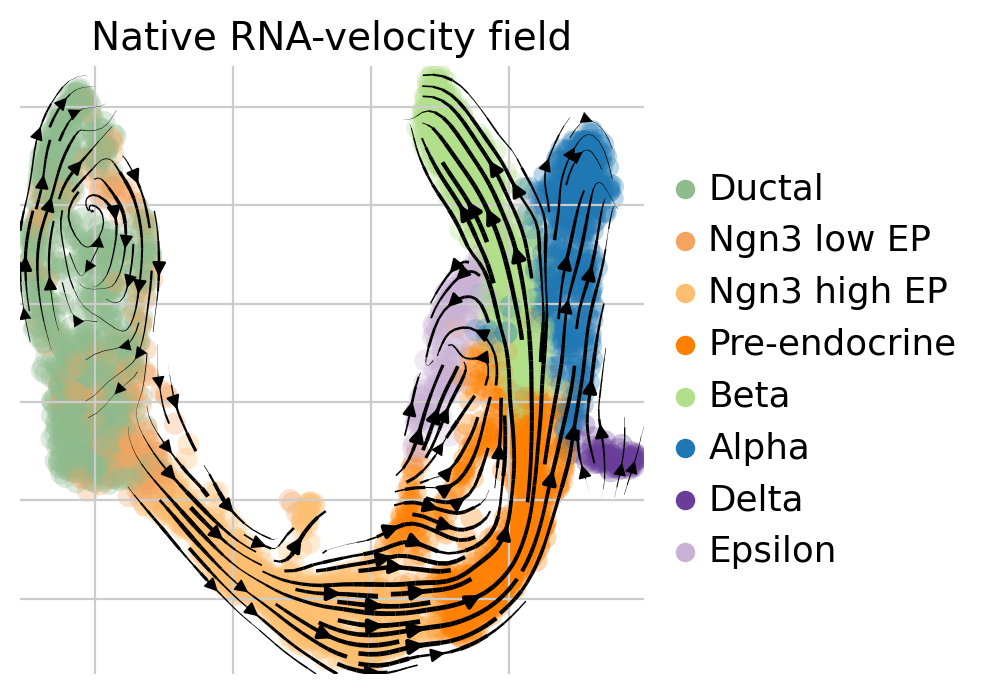

In [5]:
native_color = "clusters"
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color=native_color,
    legend_loc="right margin",
    title="Native RNA-velocity field",
)

## 4. Define the supervised furcation and future-fate settings


In [6]:
ROOT = ("Ngn3 high EP", "Pre-endocrine")
FATES = ["Alpha", "Beta", "Delta", "Epsilon"]
OBS_KEY = "clusters"
ORDERING_KEY = "latent_time"
TARGET_FATE = "Beta"
FUTURE_OPTIONS = {
    "effective_horizon": 64,
    "anchor_quantile": 0.90,
    "min_anchor_cells": 10,
    "progression_scale": "rank",
}

## 5. Real-study metadata or controlled demonstration design

A scientific analysis must use genuine biological replicates. The controlled
demonstration balances state and ordering composition across pseudo-replicates,
then tilts root-cell transition probabilities toward destinations with higher
baseline target-fate probability. The transition support is unchanged and every
row remains normalized.


In [7]:
def assign_stratified_demo_design(
    adata,
    *,
    annotation_key,
    ordering_key,
    conditions,
    replicates_per_condition,
    condition_key="condition",
    replicate_key="sample_id",
    n_ordering_bins=5,
    random_state=0,
):
    """Create balanced technical pseudo-conditions within state/order strata.

    This helper is for tutorial validation only. It must not replace genuine
    biological condition and replicate metadata in a scientific analysis.
    """
    annotations = adata.obs[annotation_key].astype(str)
    ordering = pd.to_numeric(adata.obs[ordering_key], errors="coerce")
    if ordering.isna().any():
        raise ValueError(f"{ordering_key!r} contains missing or nonnumeric values.")
    strata = pd.Series(index=adata.obs_names, dtype=object)
    for annotation, indices in annotations.groupby(annotations).groups.items():
        indices = pd.Index(indices)
        values = ordering.loc[indices]
        n_bins = min(n_ordering_bins, len(indices), int(values.nunique()))
        if n_bins <= 1:
            bins = pd.Series("0", index=indices)
        else:
            bins = pd.qcut(
                values.rank(method="first"),
                q=n_bins,
                labels=False,
                duplicates="drop",
            ).astype(str)
        strata.loc[indices] = str(annotation) + "::" + bins

    conditions = tuple(map(str, conditions))
    combinations = [
        (condition, f"{condition}_R{replicate + 1}")
        for condition in conditions
        for replicate in range(int(replicates_per_condition))
    ]
    rng = np.random.default_rng(random_state)
    assigned_condition = pd.Series(index=adata.obs_names, dtype=object)
    assigned_replicate = pd.Series(index=adata.obs_names, dtype=object)
    for _, indices in strata.groupby(strata, sort=True).groups.items():
        indices = np.asarray(list(indices), dtype=object)
        rng.shuffle(indices)
        for position, index in enumerate(indices):
            condition, replicate = combinations[position % len(combinations)]
            assigned_condition.loc[index] = condition
            assigned_replicate.loc[index] = replicate

    adata.obs[condition_key] = pd.Categorical(
        assigned_condition,
        categories=list(conditions),
        ordered=True,
    )
    adata.obs[replicate_key] = pd.Categorical(assigned_replicate)
    return pd.DataFrame(
        {
            "stratum": strata.astype(str),
            condition_key: adata.obs[condition_key].astype(str),
            replicate_key: adata.obs[replicate_key].astype(str),
        },
        index=adata.obs_names,
    )


def target_destination_score(adata, result, *, annotation_key, target_fate):
    """Map baseline target-fate probability to every destination cell."""
    score = np.zeros(adata.n_obs, dtype=float)
    selected_indices = adata.obs_names.get_indexer(result.cell_ids)
    if np.any(selected_indices < 0):
        raise ValueError("Result cells could not be aligned to AnnData.")
    fate_index = result.fate_names.index(str(target_fate))
    score[selected_indices] = result.future_fate_contribution[:, fate_index]
    terminal = adata.obs[annotation_key].astype(str).eq(str(target_fate)).to_numpy()
    score[terminal] = 1.0
    return np.clip(score, 0.0, 1.0)


def reweight_root_transitions(
    transition_matrix,
    *,
    source_mask,
    condition_labels,
    replicate_labels,
    destination_score,
    log_shift_by_condition,
    replicate_shift_sd=0.08,
    random_state=0,
):
    """Inject a controlled condition effect without changing graph support.

    Outgoing root-cell transition probabilities are tilted toward destinations
    with high baseline target-fate probability and then renormalized. This is a
    software-validation perturbation, not a model for a particular experiment.
    """
    normalized = scCS.canonicalize_transition_matrix(transition_matrix)
    transition = normalized.matrix.tocsr(copy=True)
    source_mask = np.asarray(source_mask, dtype=bool)
    conditions = np.asarray(condition_labels, dtype=str)
    replicates = np.asarray(replicate_labels, dtype=str)
    destination_score = np.asarray(destination_score, dtype=float)
    if source_mask.shape != (transition.shape[0],):
        raise ValueError("source_mask must align to transition rows.")
    if destination_score.shape != (transition.shape[0],):
        raise ValueError("destination_score must align to transition columns.")

    rng = np.random.default_rng(random_state)
    replicate_effect = {
        replicate: float(rng.normal(0.0, replicate_shift_sd)) for replicate in np.unique(replicates)
    }
    affected = np.zeros(transition.shape[0], dtype=bool)
    for row in np.flatnonzero(source_mask):
        condition = conditions[row]
        if condition not in log_shift_by_condition:
            raise KeyError(f"Missing log shift for condition {condition!r}.")
        start, stop = transition.indptr[row], transition.indptr[row + 1]
        columns = transition.indices[start:stop]
        if len(columns) == 0:
            continue
        shift = float(log_shift_by_condition[condition]) + replicate_effect[replicates[row]]
        multipliers = np.exp(shift * destination_score[columns])
        if np.max(np.abs(multipliers - 1.0)) > 1e-12:
            affected[row] = True
        transition.data[start:stop] *= multipliers
        row_sum = float(transition.data[start:stop].sum())
        if row_sum > 0:
            transition.data[start:stop] /= row_sum
    audit = {
        "affected_root_fraction": float(np.mean(affected[source_mask])),
        "max_row_sum_error": float(
            np.max(np.abs(np.asarray(transition.sum(axis=1)).ravel() - 1.0))
        ),
        "replicate_shift_sd": float(replicate_shift_sd),
        "log_shift_by_condition": dict(log_shift_by_condition),
    }
    return transition, audit

In [8]:
original_transition = scCS.get_scvelo_transition_matrix(adata)

if DEMO_MODE:
    assignments = assign_stratified_demo_design(
        adata,
        annotation_key=OBS_KEY,
        ordering_key=ORDERING_KEY,
        conditions=CONDITIONS,
        replicates_per_condition=REPLICATES_PER_CONDITION,
        condition_key=CONDITION_KEY,
        replicate_key=REPLICATE_KEY,
        random_state=SEED,
    )
    baseline_scorer = scCS.SingleScorer(
        adata,
        root=ROOT,
        branches=FATES,
        obs_key=OBS_KEY,
    )
    baseline_scorer.build_embedding(ordering_metric=ORDERING_KEY, verbose=False)
    baseline_scorer.fit(
        transition_matrix=original_transition,
        scoring_mode="future_fate",
        future_fate_options=FUTURE_OPTIONS,
        verbose=False,
    )
    baseline_result = baseline_scorer.score(write_to_adata=False, verbose=False)
    destination_score = target_destination_score(
        adata,
        baseline_result,
        annotation_key=OBS_KEY,
        target_fate=TARGET_FATE,
    )
    labels = adata.obs[OBS_KEY].astype(str)
    root_labels = {ROOT} if isinstance(ROOT, str) else set(ROOT)
    root_mask_full = labels.isin(root_labels).to_numpy()
    analysis_transition, perturbation_audit = reweight_root_transitions(
        original_transition,
        source_mask=root_mask_full,
        condition_labels=adata.obs[CONDITION_KEY].astype(str).to_numpy(),
        replicate_labels=adata.obs[REPLICATE_KEY].astype(str).to_numpy(),
        destination_score=destination_score,
        log_shift_by_condition={"control": 0.0, "treated": 1.25},
        replicate_shift_sd=0.08,
        random_state=SEED + 1,
    )
    display(pd.Series(perturbation_audit, name="value").to_frame())
else:
    required = {CONDITION_KEY, REPLICATE_KEY}
    missing = sorted(required - set(adata.obs.columns))
    if missing:
        raise KeyError(f"Missing real-study metadata columns: {missing}")
    analysis_transition = original_transition

design_balance = (
    adata.obs.groupby([CONDITION_KEY, REPLICATE_KEY], observed=True)
    .size()
    .rename("n_cells")
    .reset_index()
)
display(design_balance)

,value
affected_root_fraction,1.0
max_row_sum_error,0.0
replicate_shift_sd,0.08
log_shift_by_condition,"{'control': 0.0, 'treated': 1.25}"


,condition,sample_id,n_cells
0,control,control_R1,385
1,control,control_R2,385
2,control,control_R3,382
3,control,control_R4,376
4,control,control_R5,370
5,treated,treated_R1,370
6,treated,treated_R2,366
7,treated,treated_R3,365
8,treated,treated_R4,352
9,treated,treated_R5,345


## 6. Construct PairScorer, preflight, and fit one pooled model


In [9]:
pair = scCS.PairScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key=OBS_KEY,
    condition_obs_key=CONDITION_KEY,
    replicate_obs_key=REPLICATE_KEY,
    condition_order=list(CONDITIONS),
)
preflight = pair.preflight(ordering_metric=ORDERING_KEY, check_velocity=True)
preflight.display()
preflight.raise_for_errors()
pair.build_embedding(ordering_metric=ORDERING_KEY)
pair.fit(
    transition_matrix=analysis_transition,
    scoring_mode="future_fate",
    transition_scope="pooled",
    future_fate_options=FUTURE_OPTIONS,
)
results = pair.score_all_conditions(
    population="root",
    min_cells=20,
    min_replicates=4,
)
replicate_table = pair.replicate_table(results)
display(replicate_table)
replicate_table.to_csv(OUTPUT_DIR / "replicate_outcomes.csv", index=False)

,level,code,message,value
0,info,furcation_valid,Root and terminal annotations are valid.,2518.0
1,info,root_cells,Root population contains 1234 cells.,1234.0
2,info,terminal_Alpha,Terminal 'Alpha' contains 481 cells.,481.0
3,info,terminal_Beta,Terminal 'Beta' contains 591 cells.,591.0
4,info,terminal_Delta,Terminal 'Delta' contains 70 cells.,70.0
5,info,terminal_Epsilon,Terminal 'Epsilon' contains 142 cells.,142.0
6,info,ordering_valid,Ordering metric is finite and non-constant amo...,1.0
7,info,ordering_resolution,Root ordering has 1234 unique values across 12...,1.0
8,info,velocity_available,Velocity information is available.,NaN
9,info,condition_control_cells,Condition 'control' contains 1898 cells.,1898.0


[scCS] Scientific star built for 2518 cells in 4 dimensions.
       Root radial clipping: 0.050 low / 0.050 high
       Terminal scientific coordinates: fixed equal-radius simplex vertices (radius=1.000).
scCS FutureFateScoreResult
  Furcation: root -> ['Alpha', 'Beta', 'Delta', 'Epsilon']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 2518 selected; 1234 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.637
  Root mean future-fate entropy: 0.546
  Root mean future-fate specificity: 0.454
  Root mean reach-supported specificity: 0.291
  Root mean unresolved probability: 0.363
  Root mean signed progression: 0.037
  Root future-fate composition: Alpha=0.246, Beta=0.690, Delta=0.000, Epsilon=0.064
  Solver: direct; iterations=1; residual=1.610e-15
[scCS] 'control': 625 root cells; 5 replicates.
[scCS] 'treated': 609 root cells; 5 replicates.


,condition,replicate_id,replicate_label,n_cells,n_valid_projection,mean_commitment_strength,mean_directional_entropy,mean_commitment_entropy,mean_directional_specificity,mean_nearest_fate_angle_degrees,...,pairwise_log_commitment_ratio::Alpha::Delta,pairwise_log_commitment_ratio::Delta::Alpha,pairwise_log_commitment_ratio::Alpha::Epsilon,pairwise_log_commitment_ratio::Epsilon::Alpha,pairwise_log_commitment_ratio::Beta::Delta,pairwise_log_commitment_ratio::Delta::Beta,pairwise_log_commitment_ratio::Beta::Epsilon,pairwise_log_commitment_ratio::Epsilon::Beta,pairwise_log_commitment_ratio::Delta::Epsilon,pairwise_log_commitment_ratio::Epsilon::Delta
0,control,control::control_R1,control_R1,125,125,0.635930,0.556772,0.837506,0.443228,NaN,...,6.502464,-6.502464,1.299916,-1.299916,7.496403,-7.496403,2.293855,-2.293855,-5.202548,5.202548
1,control,control::control_R2,control_R2,125,125,0.632664,0.558111,0.840343,0.441889,NaN,...,6.995748,-6.995748,1.351279,-1.351279,7.972633,-7.972633,2.328164,-2.328164,-5.644469,5.644469
2,control,control::control_R3,control_R3,125,125,0.636583,0.541783,0.830323,0.458217,NaN,...,6.878208,-6.878208,1.409696,-1.409696,7.919780,-7.919780,2.451268,-2.451268,-5.468512,5.468512
3,control,control::control_R4,control_R4,125,125,0.631317,0.560588,0.841329,0.439412,NaN,...,6.801378,-6.801378,1.344525,-1.344525,7.745623,-7.745623,2.288769,-2.288769,-5.456854,5.456854
4,control,control::control_R5,control_R5,125,125,0.633810,0.554080,0.837938,0.445920,NaN,...,7.060102,-7.060102,1.424122,-1.424122,8.031143,-8.031143,2.395162,-2.395162,-5.635980,5.635980
5,treated,treated::treated_R1,treated_R1,125,125,0.644365,0.526566,0.817396,0.473434,NaN,...,6.752256,-6.752256,1.300839,-1.300839,7.893537,-7.893537,2.442121,-2.442121,-5.451417,5.451417
6,treated,treated::treated_R2,treated_R2,125,125,0.638986,0.544790,0.829909,0.455210,NaN,...,6.831015,-6.831015,1.281852,-1.281852,7.881732,-7.881732,2.332568,-2.332568,-5.549164,5.549164
7,treated,treated::treated_R3,treated_R3,125,125,0.640841,0.533247,0.822325,0.466753,NaN,...,6.719379,-6.719379,1.318600,-1.318600,7.804702,-7.804702,2.403923,-2.403923,-5.400779,5.400779
8,treated,treated::treated_R4,treated_R4,119,119,0.636384,0.542044,0.830149,0.457956,NaN,...,6.640851,-6.640851,1.248749,-1.248749,7.710124,-7.710124,2.318022,-2.318022,-5.392102,5.392102
9,treated,treated::treated_R5,treated_R5,115,115,0.638387,0.540470,0.828557,0.459530,NaN,...,6.938915,-6.938915,1.464080,-1.464080,7.982412,-7.982412,2.507577,-2.507577,-5.474835,5.474835


## 7. Descriptive condition summaries before hypothesis testing


In [10]:
summary_rows = []
for condition, condition_result in results.items():
    population = condition_result.population_summary
    row = {
        "condition": condition,
        "n_cells": condition_result.n_cells,
        "n_replicates": condition_result.n_replicates,
        "mean_future_fate_reach": np.nanmean(condition_result.commitment_strength),
        "mean_future_fate_entropy": np.nanmean(condition_result.directional_entropy),
        "mean_future_fate_specificity": np.nanmean(condition_result.directional_specificity),
        "mean_reach_supported_specificity": np.nanmean(condition_result.specific_commitment),
        "mean_signed_progression": np.nanmean(condition_result.progression_velocity),
        "mean_selected_path_coverage": np.nanmean(condition_result.transition_coverage),
        "population_balance_entropy": population.population_balance_entropy,
        "total_future_fate_mass": population.total_mass,
    }
    for fate_index, fate in enumerate(condition_result.fate_names):
        row[f"mean_affinity_{fate}"] = np.nanmean(
            condition_result.directional_affinity[:, fate_index]
        )
        row[f"mean_contribution_{fate}"] = np.nanmean(
            condition_result.commitment_contribution[:, fate_index]
        )
    summary_rows.append(row)
condition_summary = pd.DataFrame(summary_rows)
display(condition_summary)
condition_summary.to_csv(OUTPUT_DIR / "condition_summary.csv", index=False)

,condition,n_cells,n_replicates,mean_future_fate_reach,mean_future_fate_entropy,mean_future_fate_specificity,mean_reach_supported_specificity,mean_signed_progression,mean_selected_path_coverage,population_balance_entropy,total_future_fate_mass,mean_affinity_Alpha,mean_contribution_Alpha,mean_affinity_Beta,mean_contribution_Beta,mean_affinity_Delta,mean_contribution_Delta,mean_affinity_Epsilon,mean_contribution_Epsilon
0,control,625,5,0.634061,0.554267,0.445733,0.284188,0.041153,0.997831,0.569639,396.288054,0.255614,0.161110,0.678641,0.431622,0.000272,0.000174,0.065472,0.041155
1,treated,609,5,0.639849,0.537328,0.462672,0.298845,0.033316,0.998463,0.554947,389.668187,0.240343,0.152031,0.695239,0.447012,0.000269,0.000174,0.064149,0.040632


## 8. Primary target-fate comparison with permutation and hierarchical bootstrap


In [11]:
target_affinity_stats = pair.compare_conditions(
    results,
    condition_a=CONDITIONS[0],
    condition_b=CONDITIONS[1],
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    n_permutations=9999,
    n_bootstrap=2000,
    confidence_level=0.95,
    random_state=SEED,
)
target_contribution_stats = pair.compare_conditions(
    results,
    metric="future_fate_contribution",
    fate=TARGET_FATE,
    n_permutations=9999,
    n_bootstrap=2000,
    random_state=SEED + 1,
)
display(target_affinity_stats)
display(target_contribution_stats)

[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_affinity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='mean_commitment_contribution'.


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward Beta,Beta,None,None,control,treated,0.678641,0.695184,...,exact,252,5,5,0.02381,0.003381,0.029842,0.95,2000,True


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward Beta,Beta,None,None,control,treated,0.431622,0.446928,...,exact,252,5,5,0.02381,0.003258,0.02716,0.95,2000,True


## 9. Full fate-wise and scalar outcome battery


In [12]:
fate_affinity_stats = pair.compare_conditions(
    results,
    metric="future_fate_affinity",
    n_permutations=9999,
    n_bootstrap=1000,
    random_state=SEED + 2,
)
fate_contribution_stats = pair.compare_conditions(
    results,
    metric="future_fate_contribution",
    n_permutations=9999,
    n_bootstrap=1000,
    random_state=SEED + 3,
)
scalar_tables = []
for offset, metric in enumerate(
    (
        "future_fate_reach",
        "future_fate_specificity",
        "reach_supported_specificity",
        "future_fate_entropy",
        "signed_progression",
        "selected_path_coverage",
    )
):
    table = pair.compare_conditions(
        results,
        metric=metric,
        n_permutations=9999,
        n_bootstrap=1000,
        random_state=SEED + 10 + offset,
    )
    scalar_tables.append(table)
scalar_stats = pd.concat(scalar_tables, ignore_index=True)
display(fate_affinity_stats)
display(fate_contribution_stats)
display(scalar_stats)
fate_affinity_stats.to_csv(OUTPUT_DIR / "fate_affinity_statistics.csv", index=False)
fate_contribution_stats.to_csv(OUTPUT_DIR / "fate_contribution_statistics.csv", index=False)
scalar_stats.to_csv(OUTPUT_DIR / "scalar_statistics.csv", index=False)

[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_affinity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='mean_commitment_contribution'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='commitment_strength'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_specificity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='specific_commitment'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_entropy'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='progression_velocity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='transition_coverage'.


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward Alpha,Alpha,None,None,control,treated,0.255614,0.240460,...,exact,252,5,5,0.063492,-0.024313,-0.006212,0.95,1000,True
1,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward Beta,Beta,None,None,control,treated,0.678641,0.695184,...,exact,252,5,5,0.071429,0.002450,0.029609,0.95,1000,True
2,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward Delta,Delta,None,None,control,treated,0.000272,0.000269,...,exact,252,5,5,1.000000,-0.000082,0.000065,0.95,1000,True
3,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward Epsilon,Epsilon,None,None,control,treated,0.065472,0.064086,...,exact,252,5,5,1.000000,-0.008398,0.006412,0.95,1000,True


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward Alpha,Alpha,None,None,control,treated,0.161110,0.152102,...,exact,252,5,5,0.063492,-0.015379,-0.003459,0.95,1000,True
1,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward Beta,Beta,None,None,control,treated,0.431622,0.446928,...,exact,252,5,5,0.071429,0.004137,0.027325,0.95,1000,True
2,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward Delta,Delta,None,None,control,treated,0.000174,0.000174,...,exact,252,5,5,1.000000,-0.000050,0.000044,0.95,1000,True
3,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward Epsilon,Epsilon,None,None,control,treated,0.041155,0.040589,...,exact,252,5,5,1.000000,-0.005454,0.003810,0.95,1000,True


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,commitment_strength,future_fate_reach,Discounted Fate Reach (DFR),None,None,None,control,treated,0.634061,0.639793,...,exact,252,5,5,0.015873,-0.000636,0.012935,0.95,1000,True
1,directional_specificity,future_fate_specificity,Future-Fate Specificity (FFS),None,None,None,control,treated,0.445733,0.462576,...,exact,252,5,5,0.023810,0.004753,0.029080,0.95,1000,True
2,specific_commitment,reach_supported_specificity,Resolved Commitment (RC),None,None,None,control,treated,0.284188,0.298742,...,exact,252,5,5,0.023810,0.003100,0.026106,0.95,1000,True
3,directional_entropy,future_fate_entropy,Future-fate entropy,None,None,None,control,treated,0.554267,0.537424,...,exact,252,5,5,0.023810,-0.028709,-0.005731,0.95,1000,True
4,progression_velocity,signed_progression,Signed Ordering Flux (SOF),None,None,None,control,treated,0.041153,0.033386,...,exact,252,5,5,0.055556,-0.020465,0.004322,0.95,1000,True
5,transition_coverage,selected_path_coverage,Selected-path coverage,None,None,None,control,treated,0.997831,0.998463,...,exact,252,5,5,0.444444,-0.001073,0.002524,0.95,1000,True


## 10. Replicate-first effect visualizations


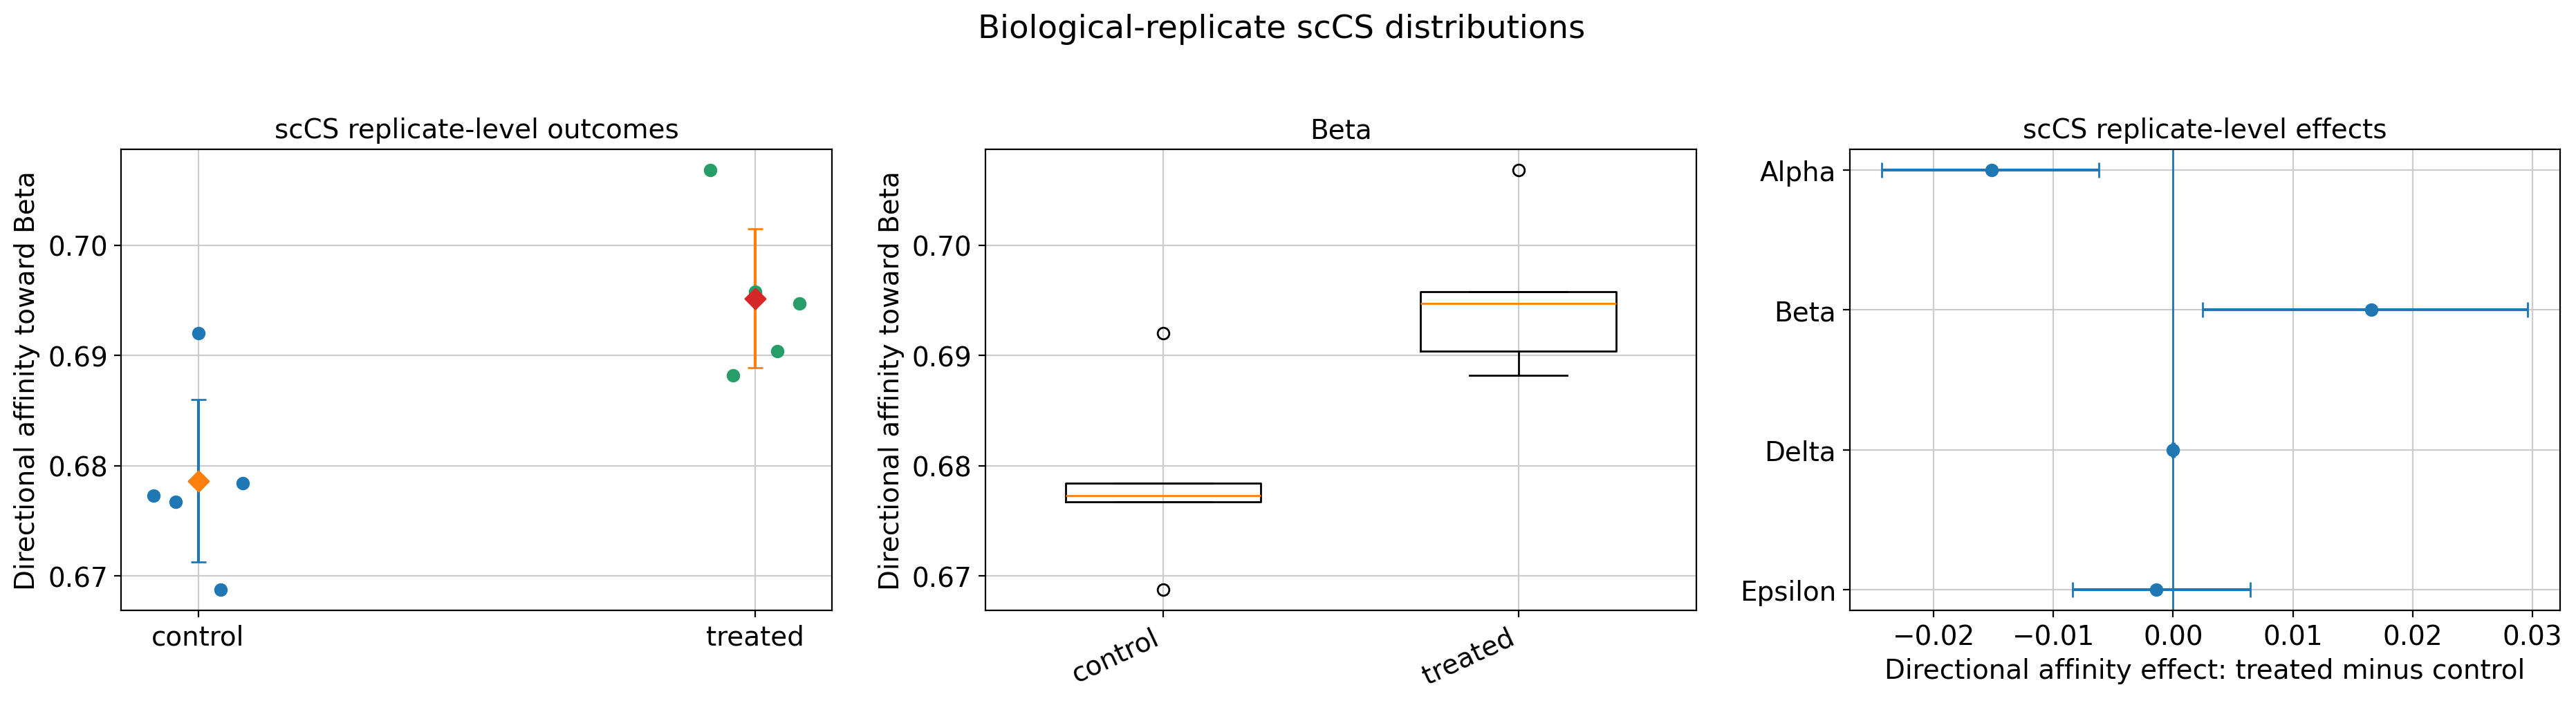

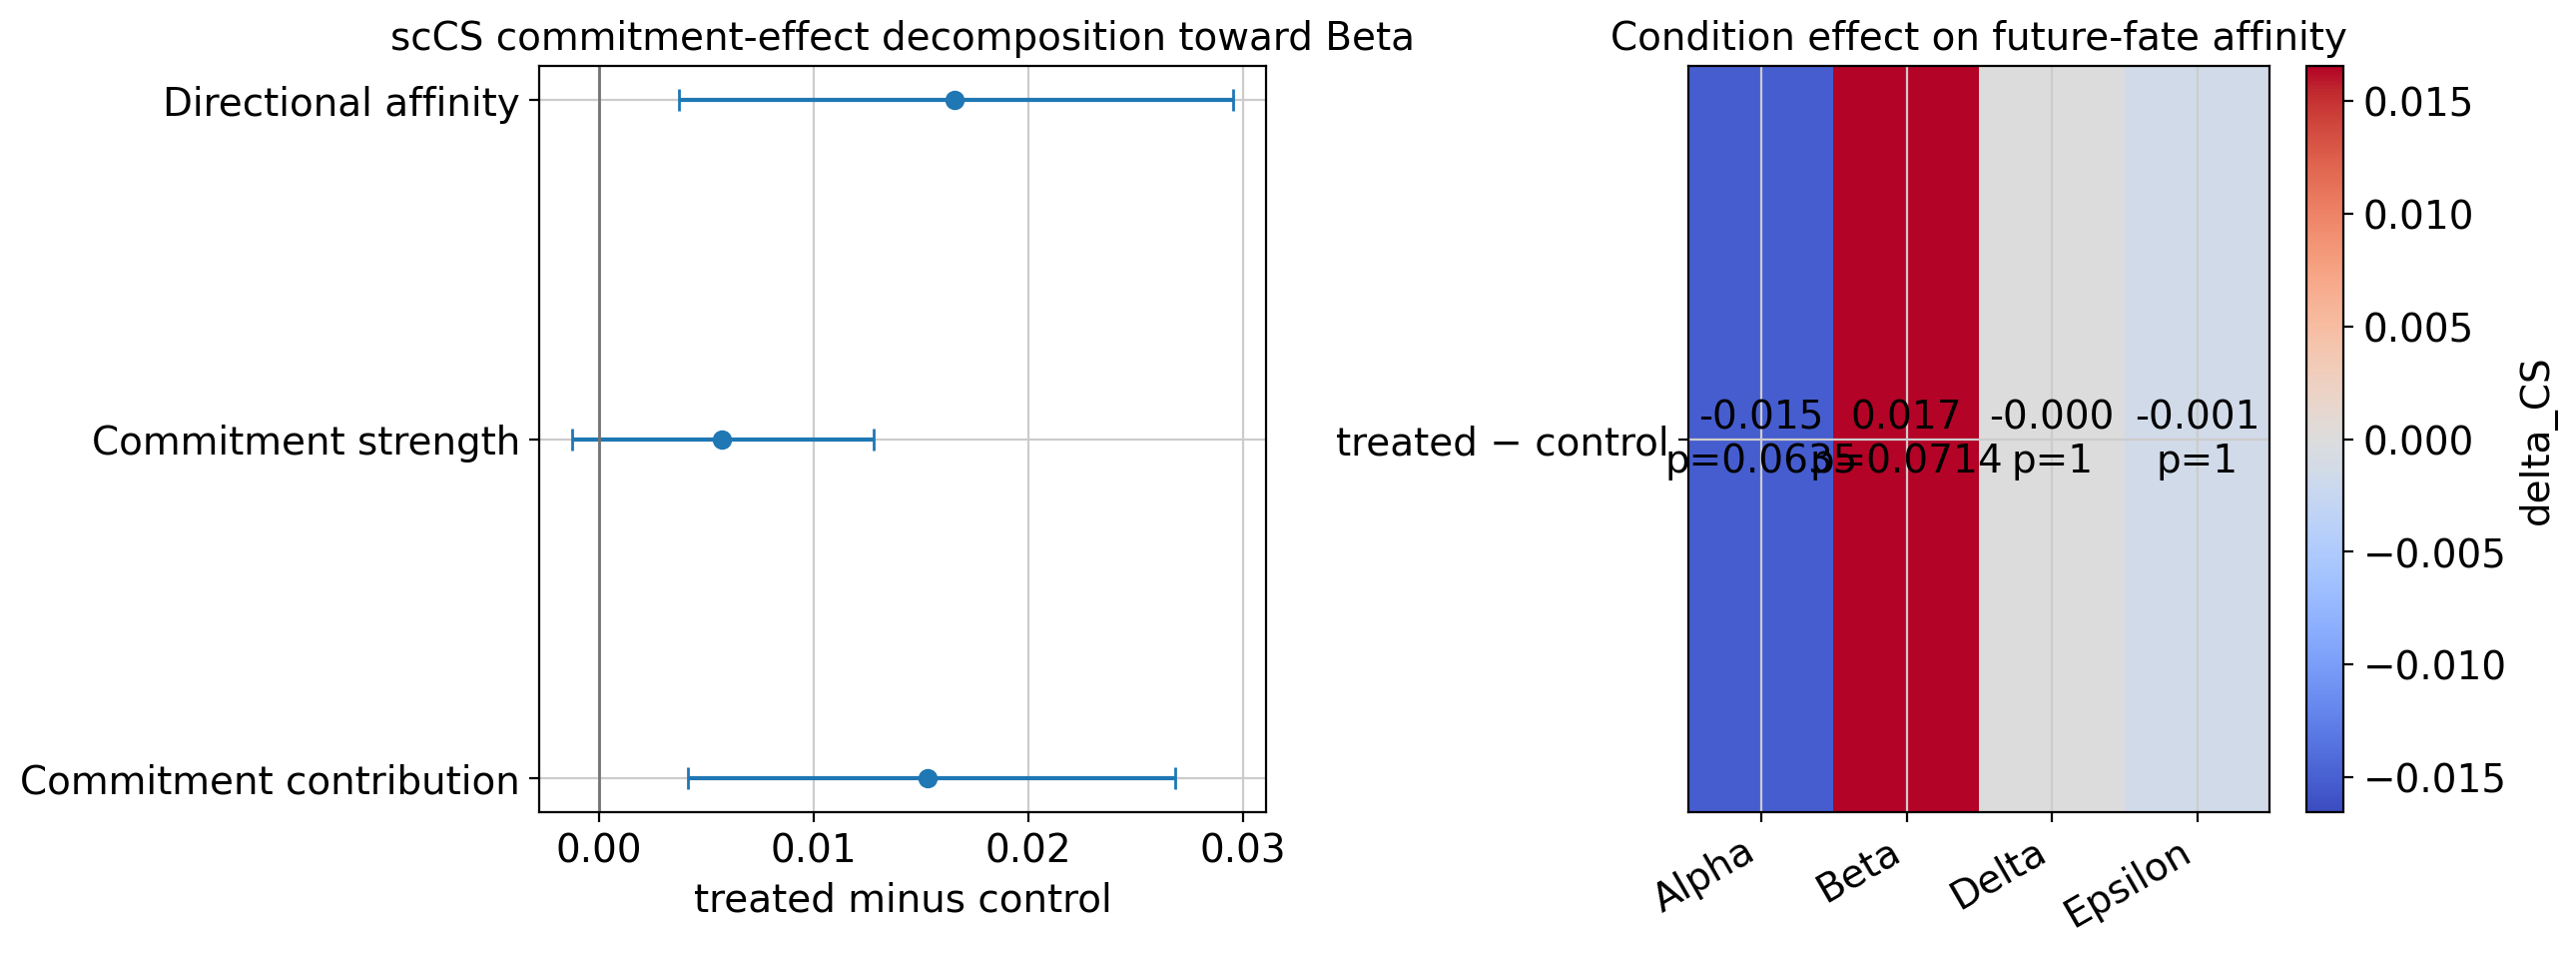

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
pair.plot_replicate_outcomes(
    results,
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    ax=axes[0],
)
pair.plot_affinity_distributions(
    results,
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    plot_type="box",
    ax=axes[1],
)
pair.plot_effects(fate_affinity_stats, ax=axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "replicate_effects.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pair.plot_commitment_decomposition(
    results,
    fate=TARGET_FATE,
    n_bootstrap=2000,
    random_state=SEED,
    ax=axes[0],
)
pair.plot_delta_CS_heatmap(
    fate_affinity_stats,
    title="Condition effect on future-fate affinity",
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "effect_decomposition_and_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Condition-specific star grids


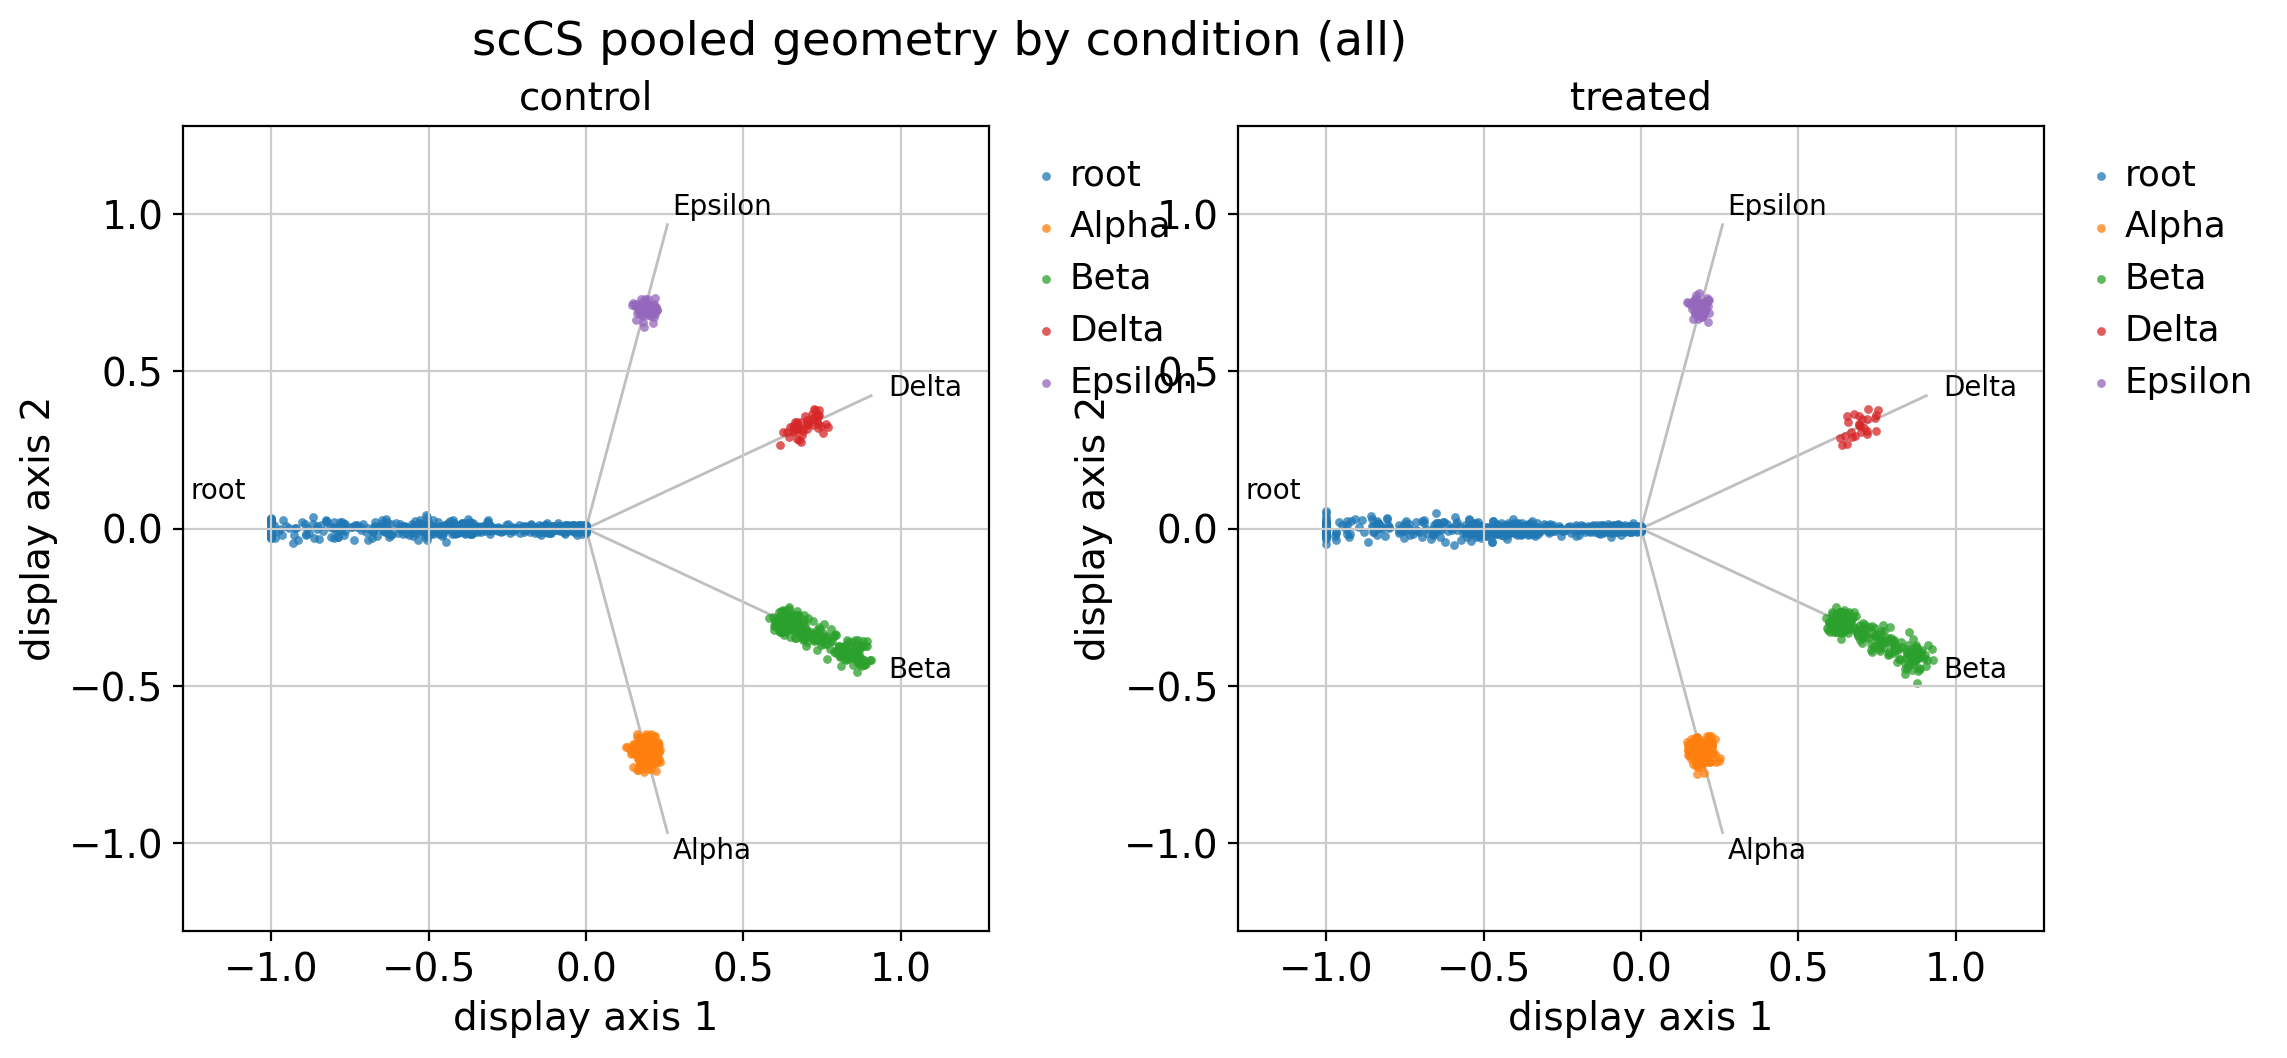

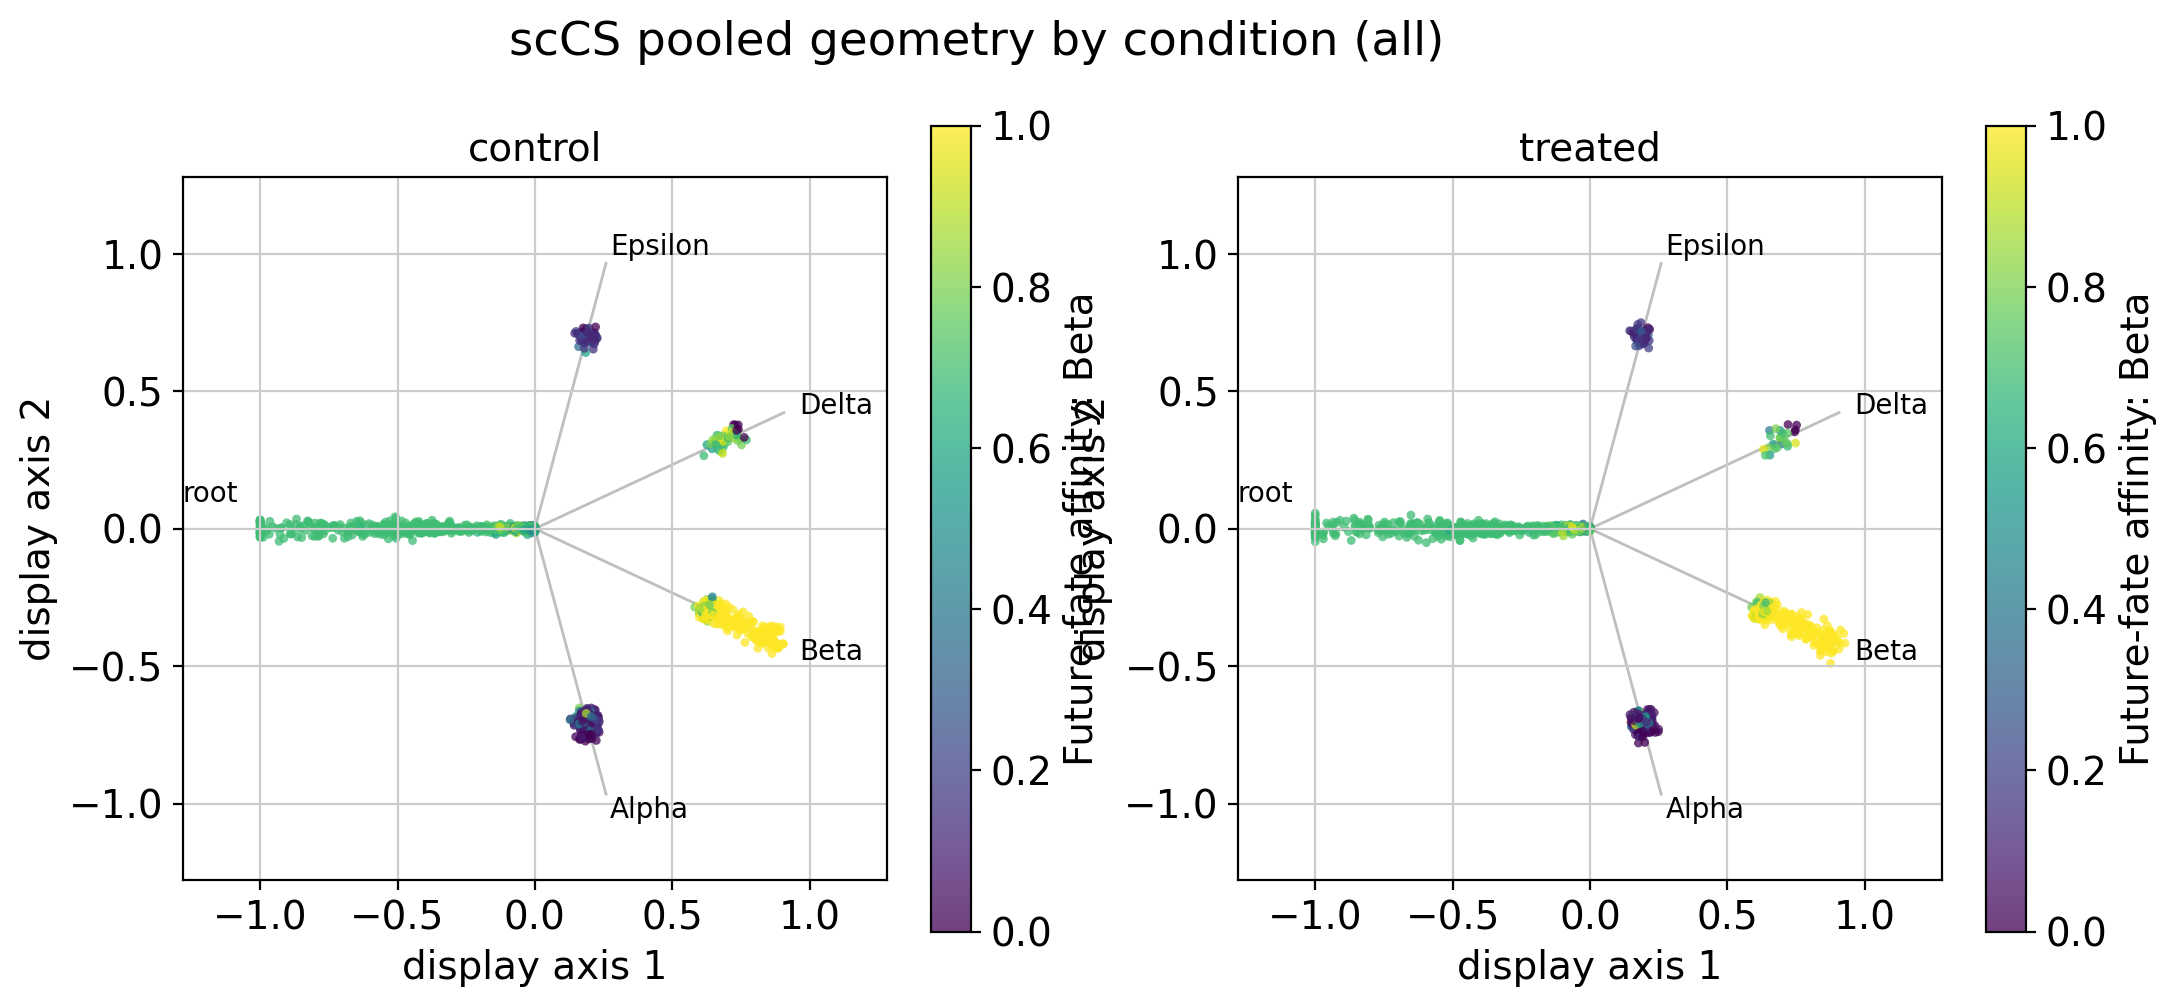

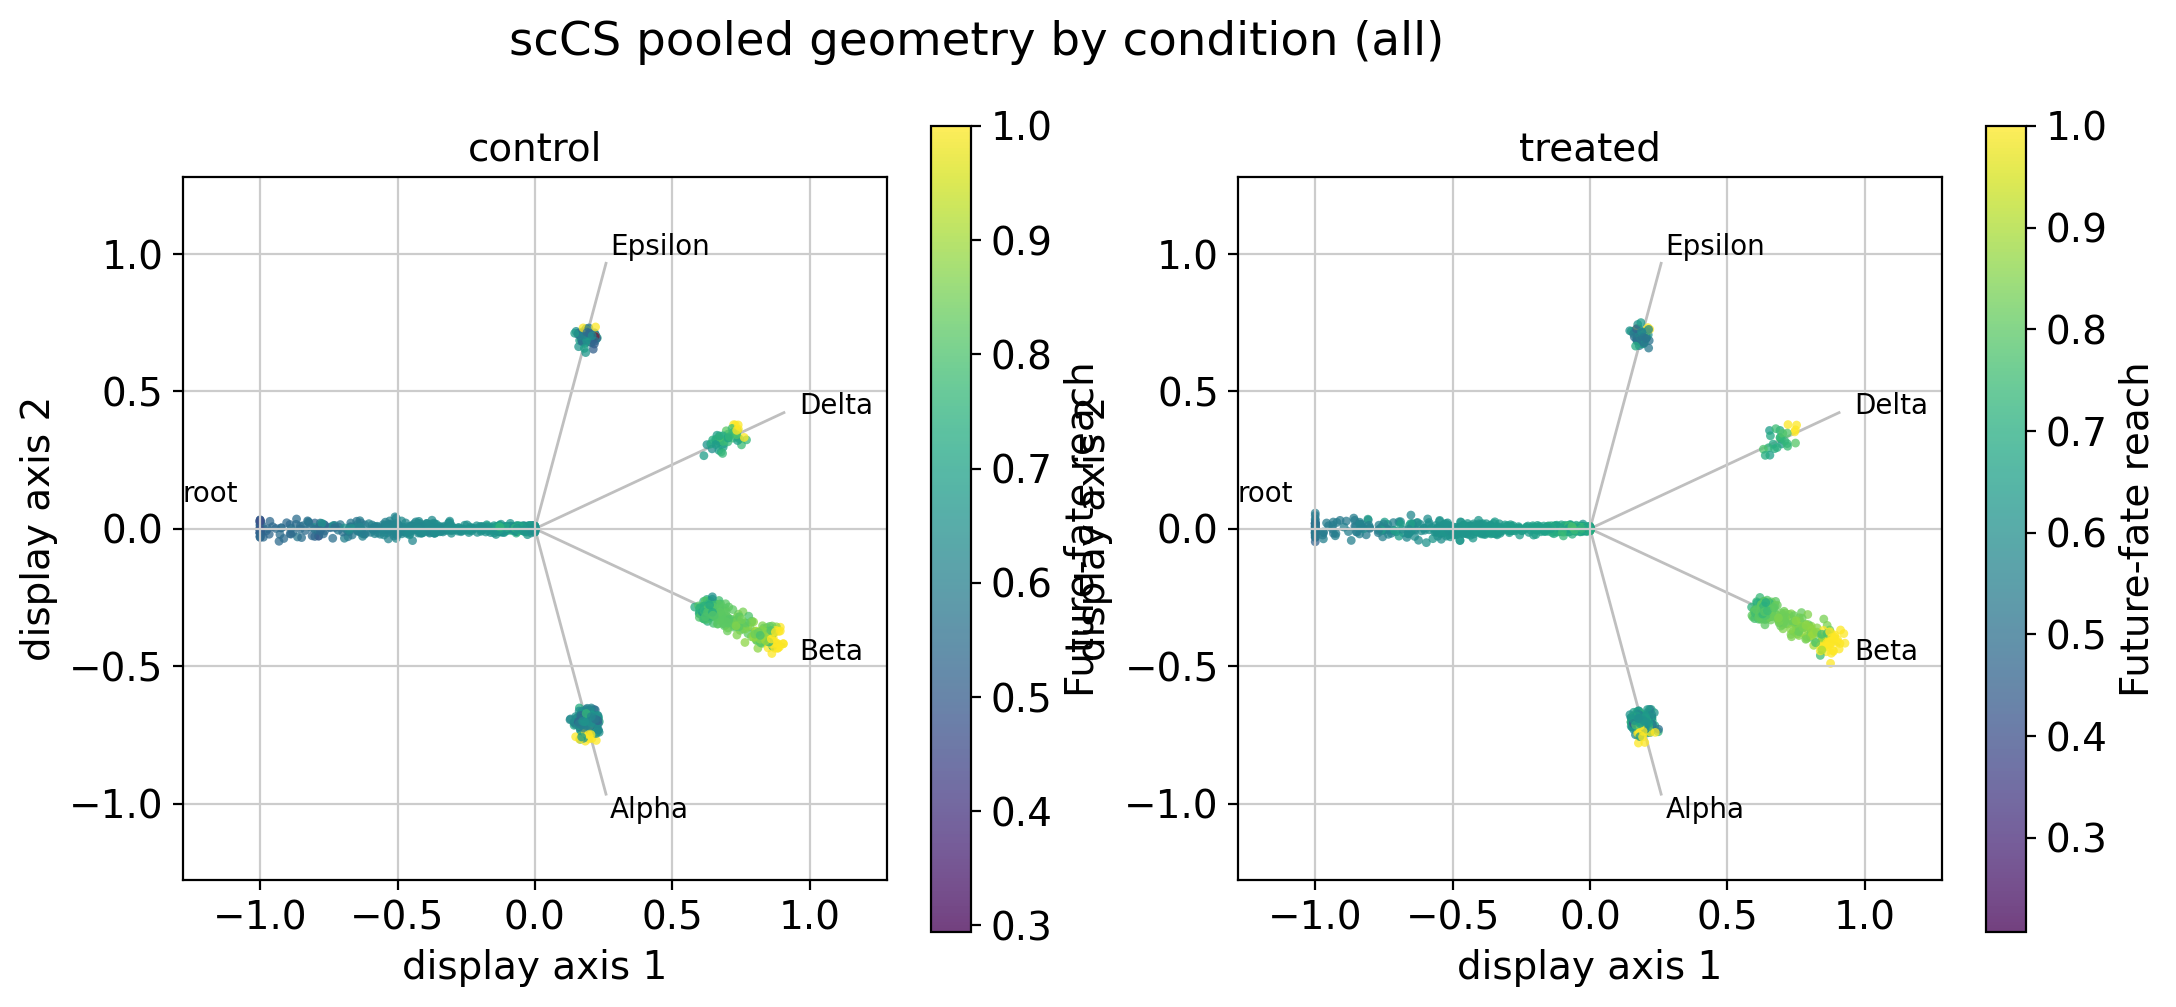

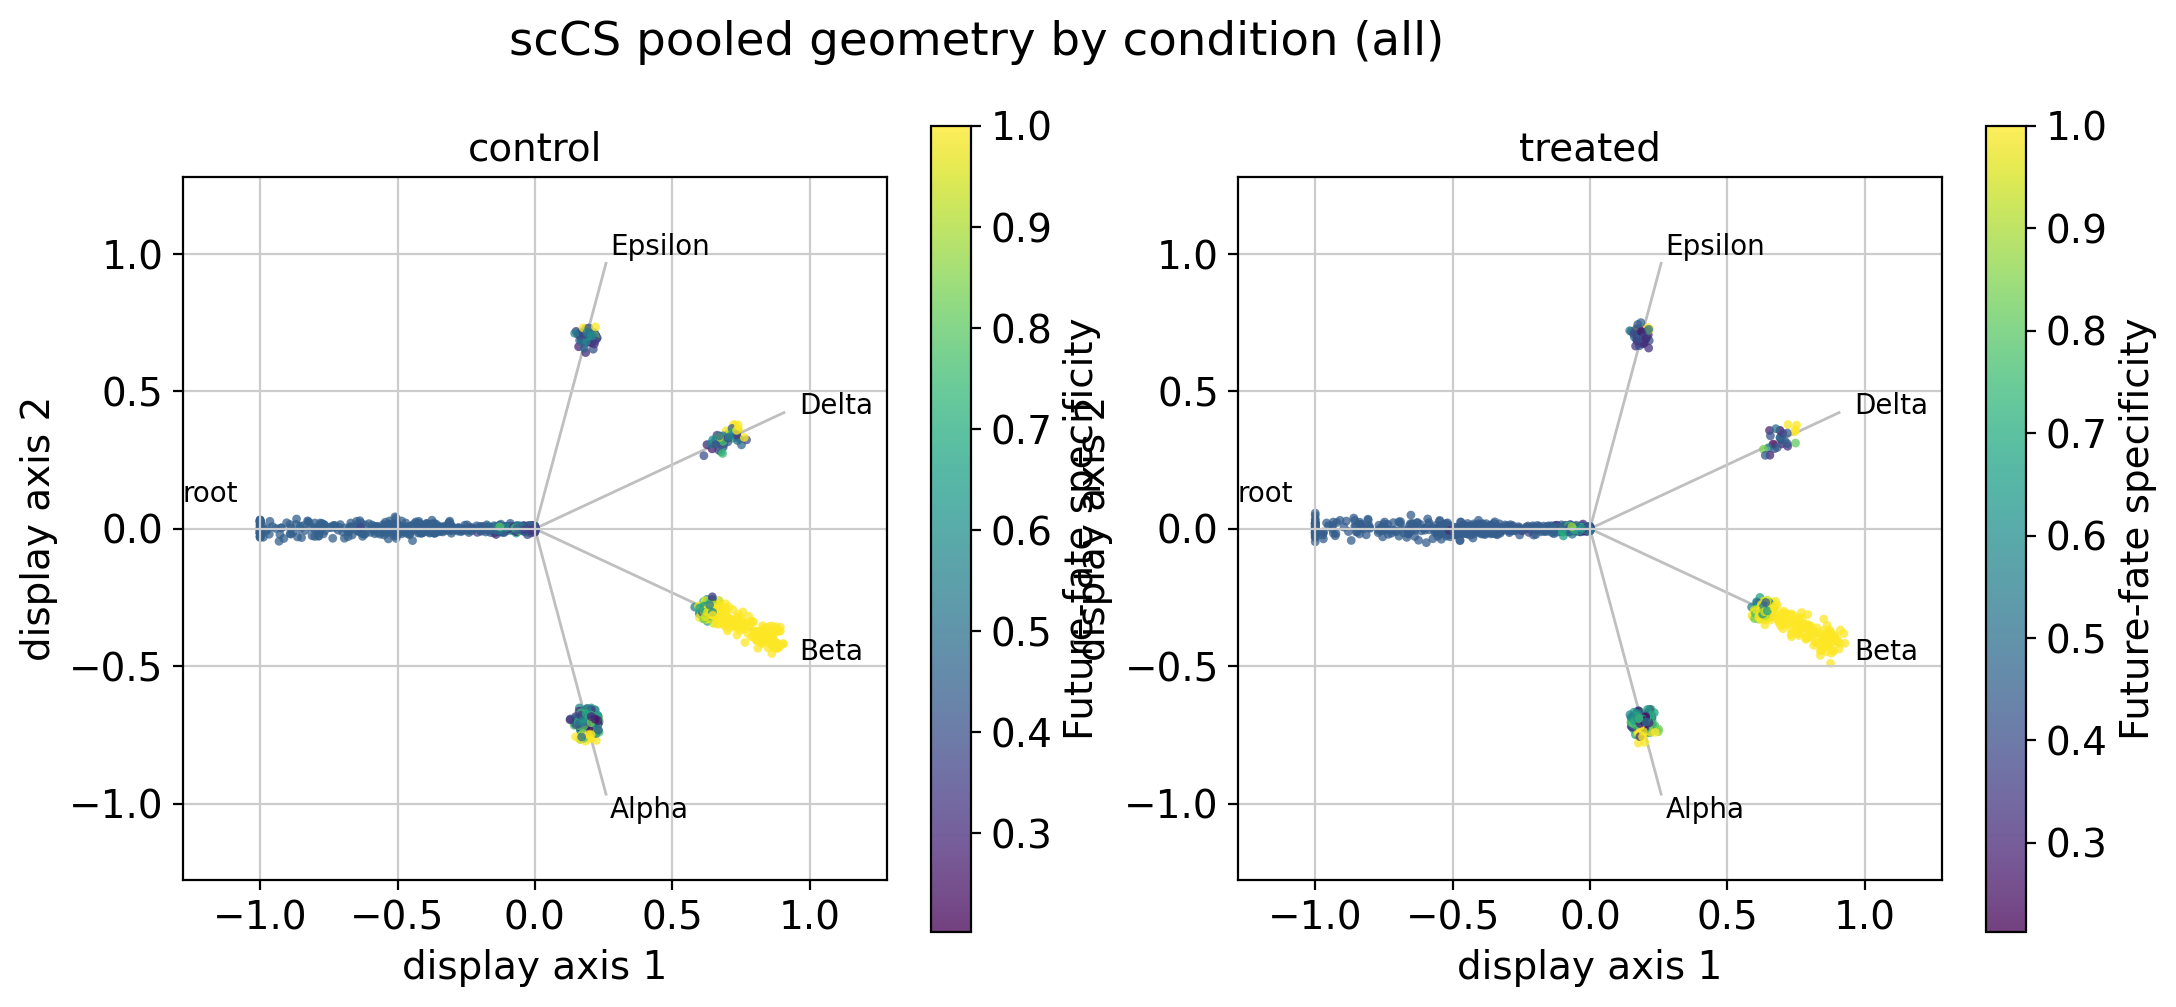

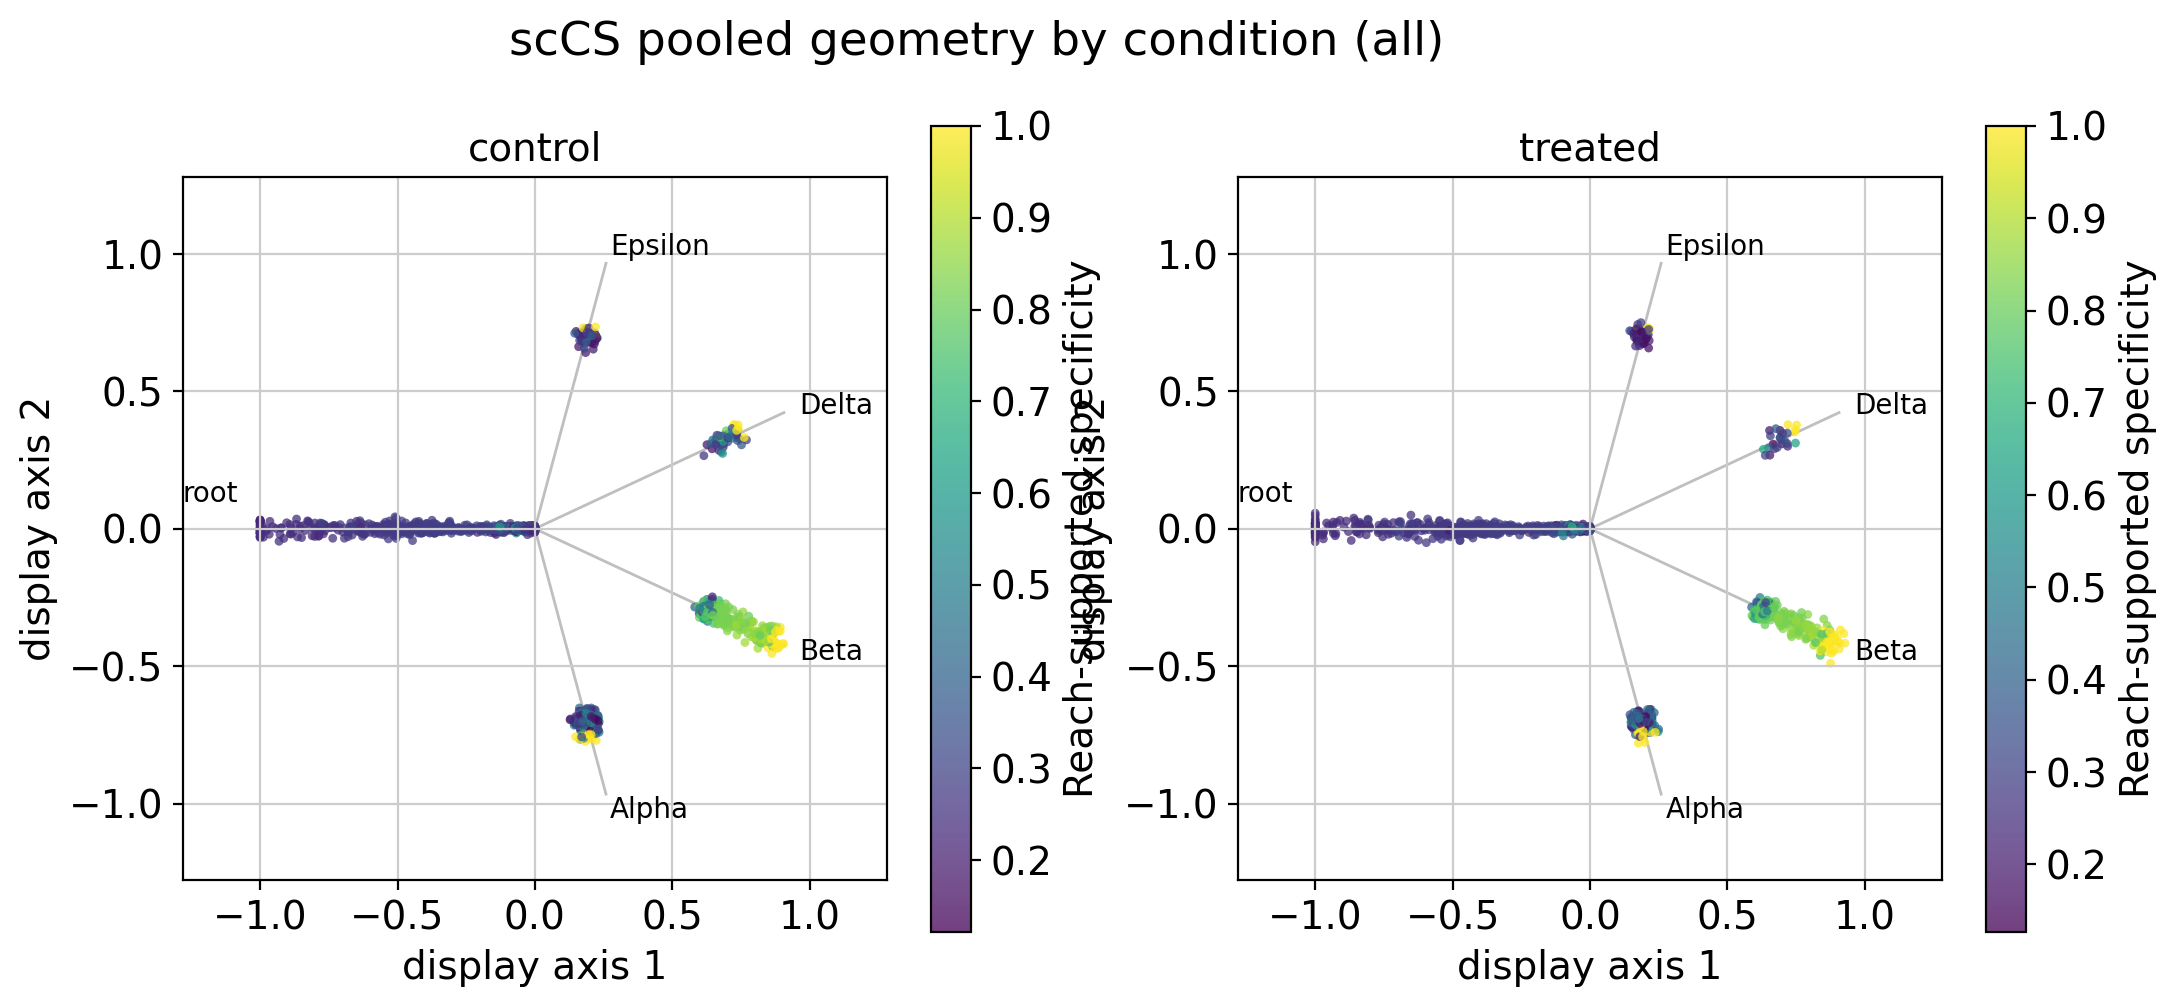

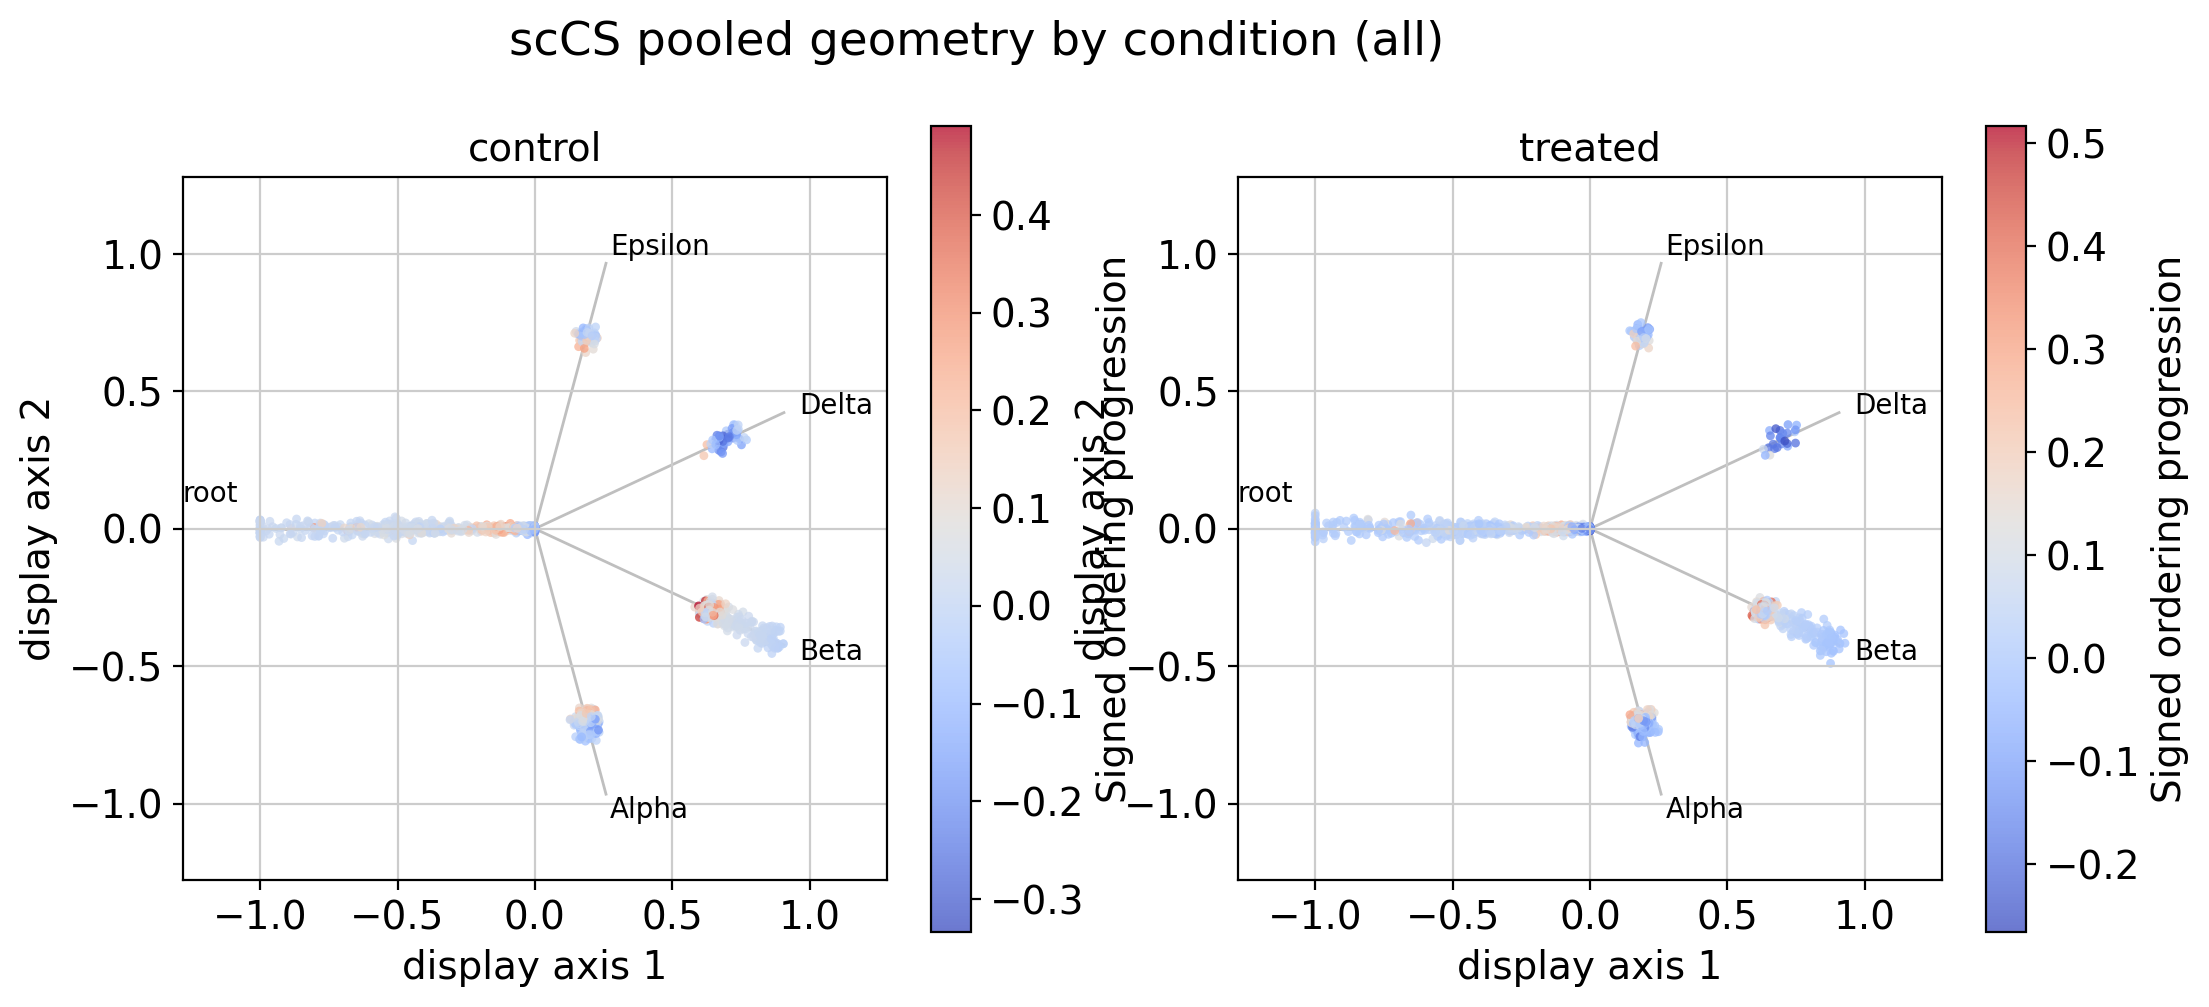

In [14]:
for color_by, filename in (
    ("population", "star_population.png"),
    (f"future_fate_affinity:{TARGET_FATE}", "star_target_affinity.png"),
    ("future_fate_reach", "star_reach.png"),
    ("future_fate_specificity", "star_specificity.png"),
    ("reach_supported_specificity", "star_supported_specificity.png"),
    ("signed_progression", "star_signed_progression.png"),
):
    figure = pair.plot_star_grid(
        results,
        color_by=color_by,
        population="all",
        ncols=2,
        cmap="coolwarm" if color_by == "signed_progression" else None,
    )
    figure.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

## 12. Condition summaries, composition, and trajectory shifts


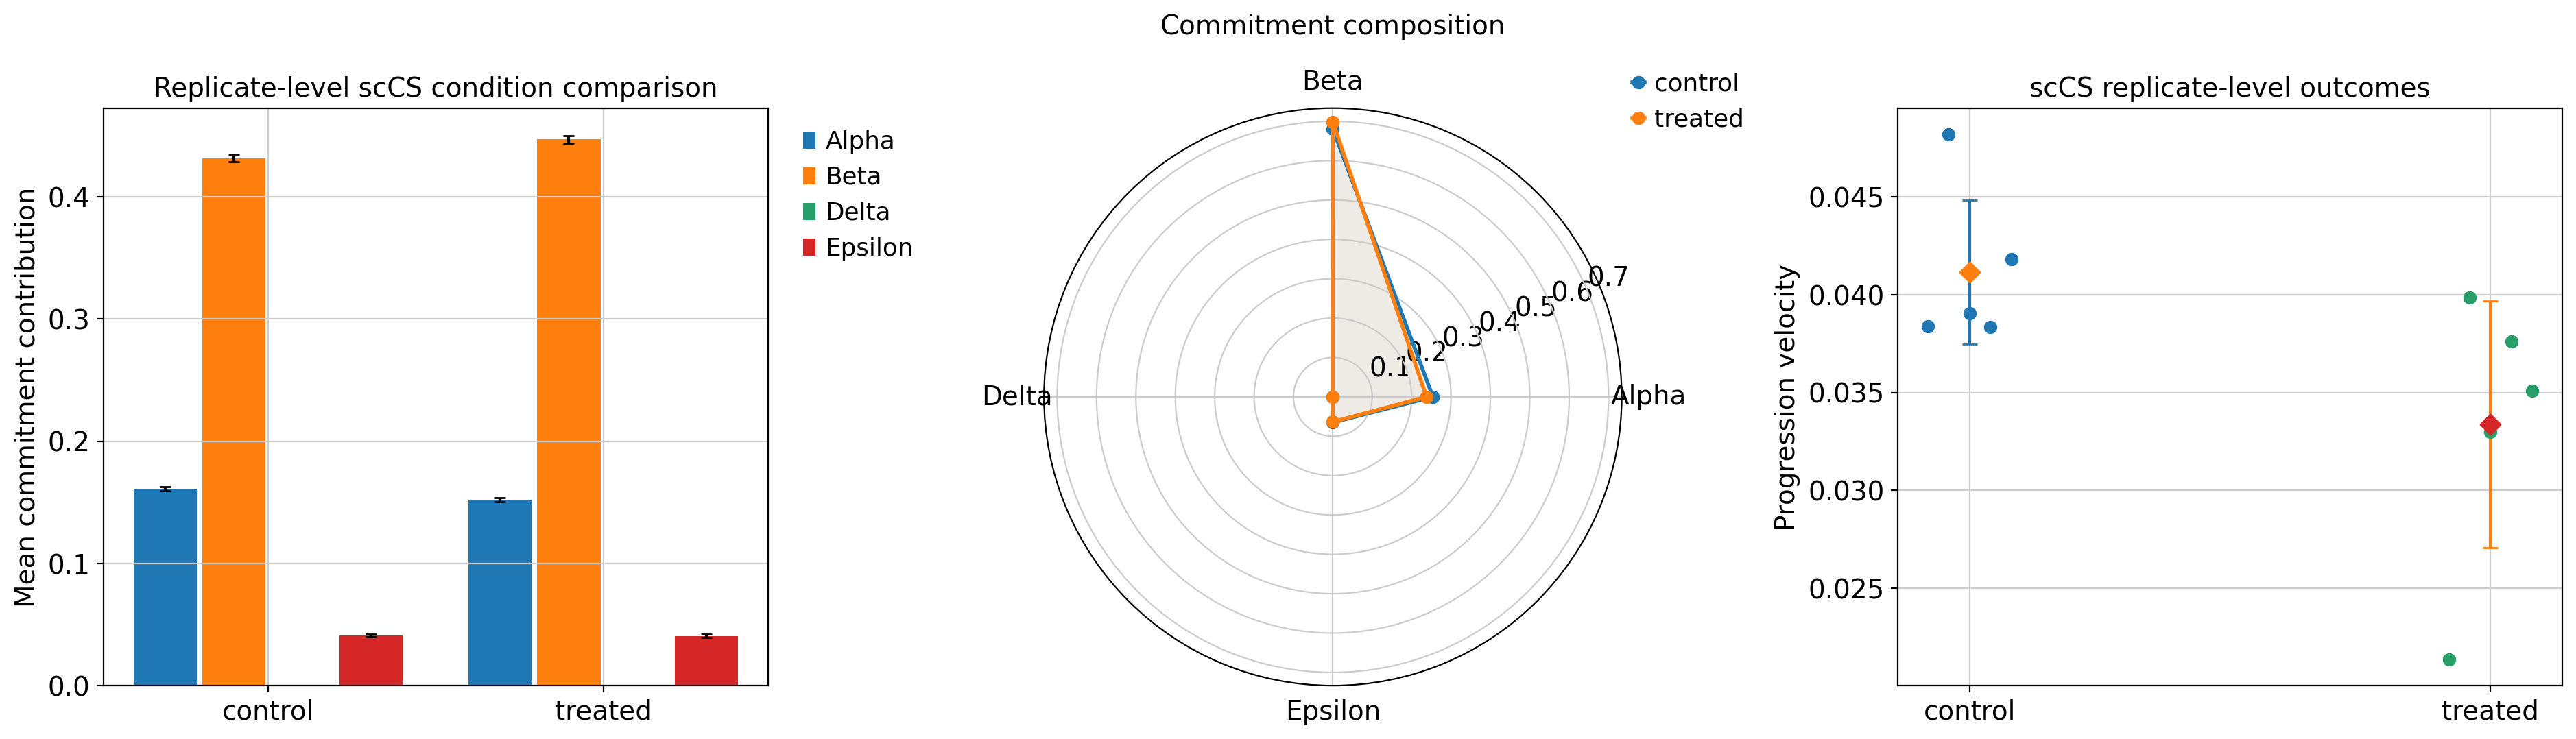

In [15]:
fig = plt.figure(figsize=(19, 5.5))
grid = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.0, 1.15])
bar_ax = fig.add_subplot(grid[0, 0])
radar_ax = fig.add_subplot(grid[0, 1], projection="polar")
progression_ax = fig.add_subplot(grid[0, 2])

pair.plot_compare_conditions_bar(
    results,
    metric="future_fate_contribution",
    ax=bar_ax,
)
pair.plot_commitment_vector_radar(
    results,
    metric="commitment_composition",
    ax=radar_ax,
)
pair.plot_trajectory_shift(results, ax=progression_ax)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "condition_summary_visuals.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Heatmaps, status composition, and transition coverage


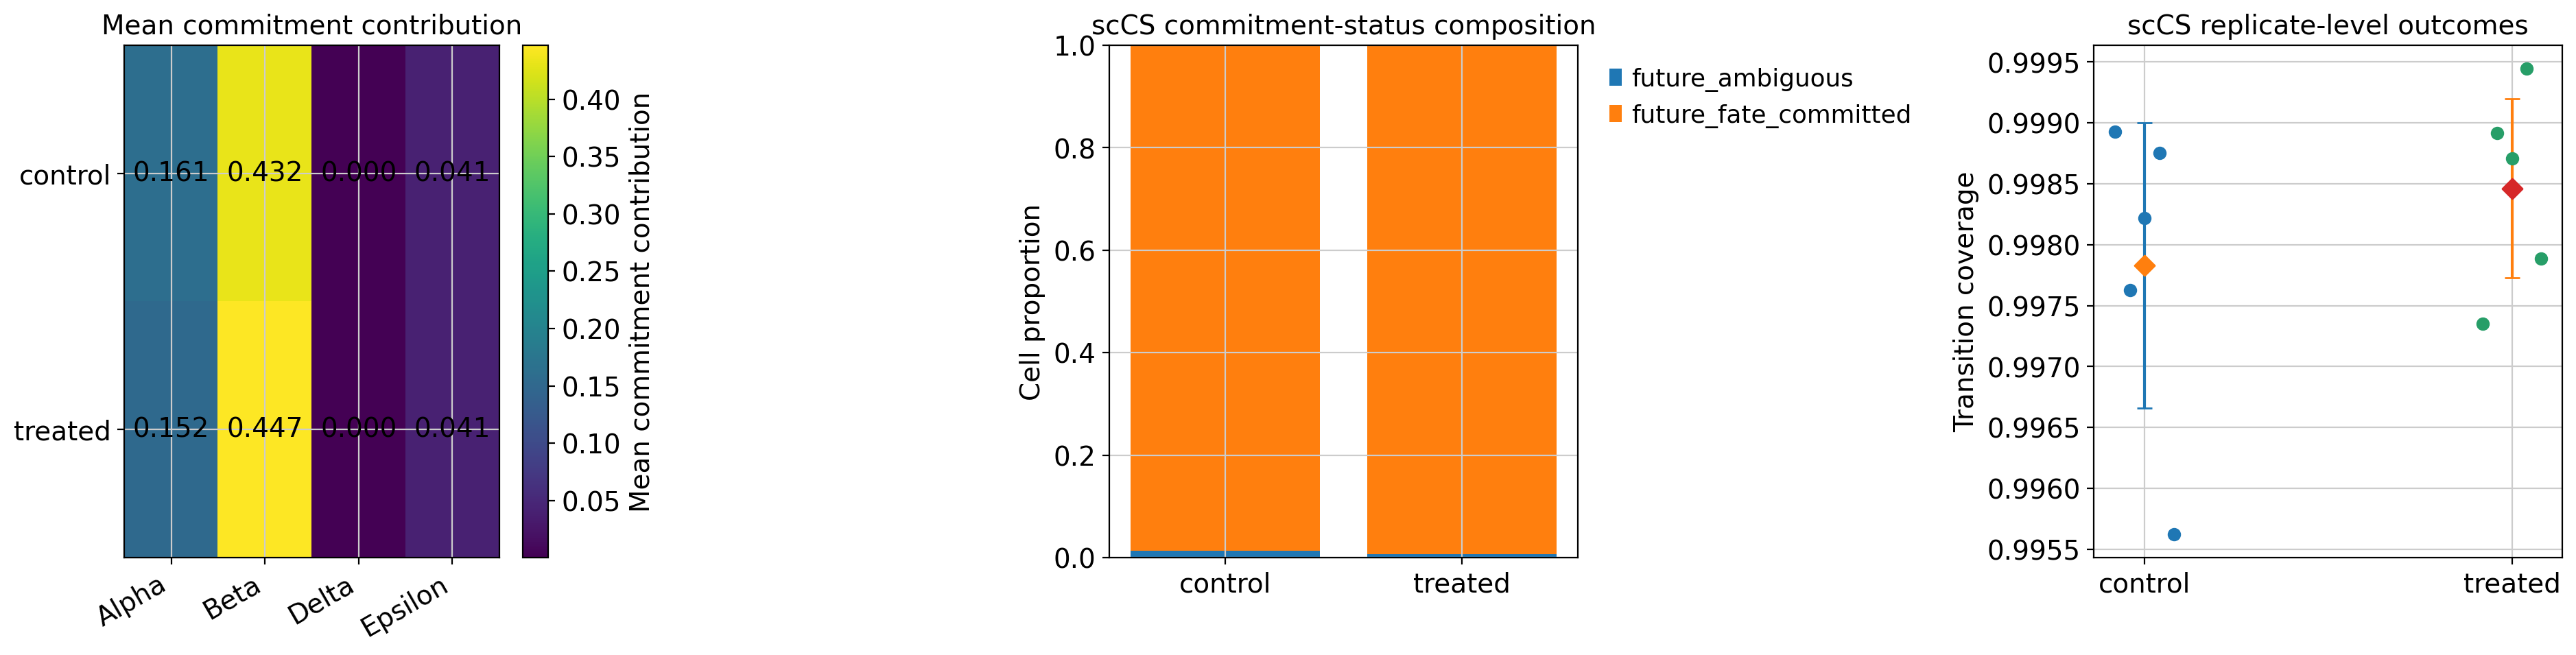

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
pair.plot_commitment_heatmap(
    results,
    metric="future_fate_contribution",
    level="condition",
    annotate=True,
    ax=axes[0],
)
pair.plot_status_composition(results, ax=axes[1])
pair.plot_transition_coverage(results, ax=axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "condition_heatmap_and_qc.png", dpi=200, bbox_inches="tight")
plt.show()

## 14. Ordering trends and display-only rose plots


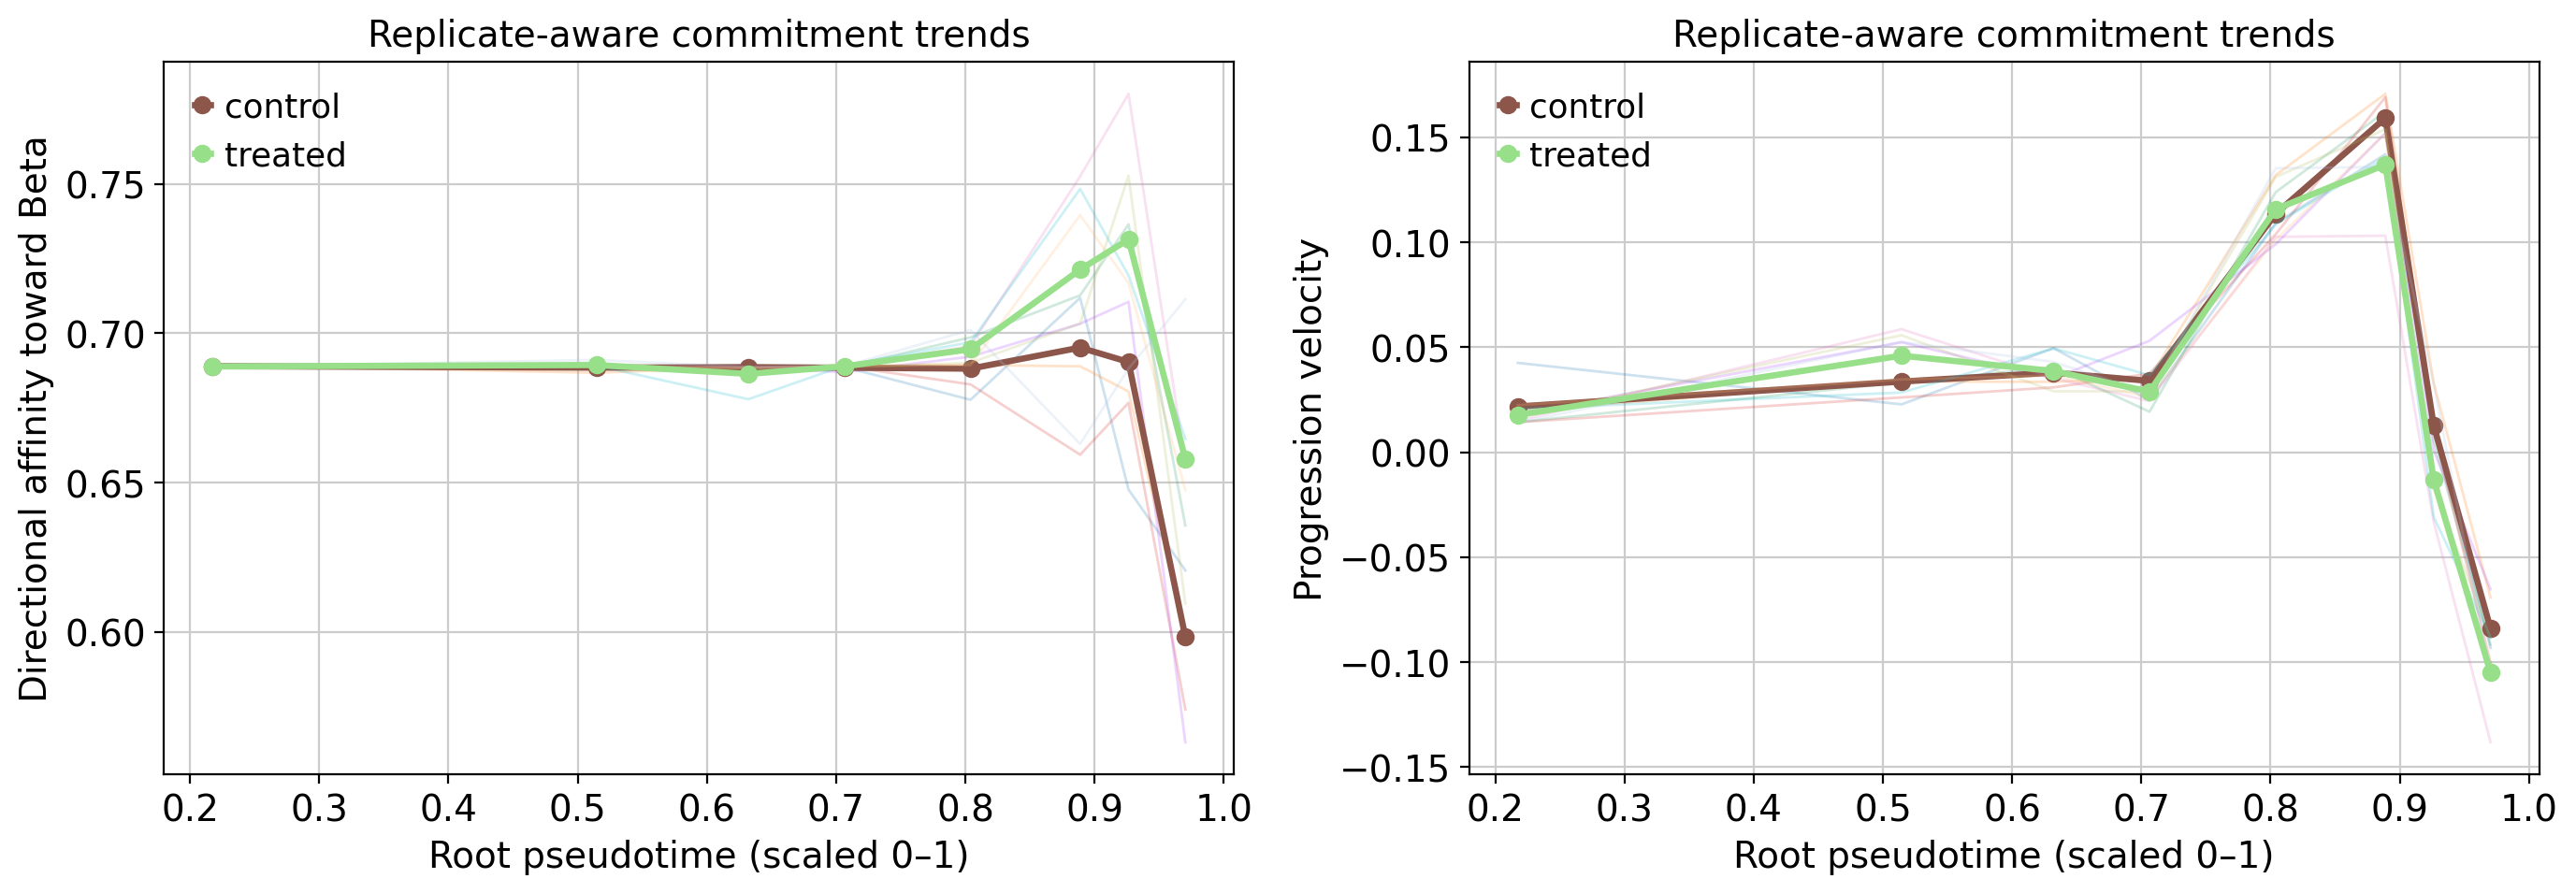

[scCS] 'control': 625 root cells; 5 replicates.
[scCS] 'treated': 609 root cells; 5 replicates.


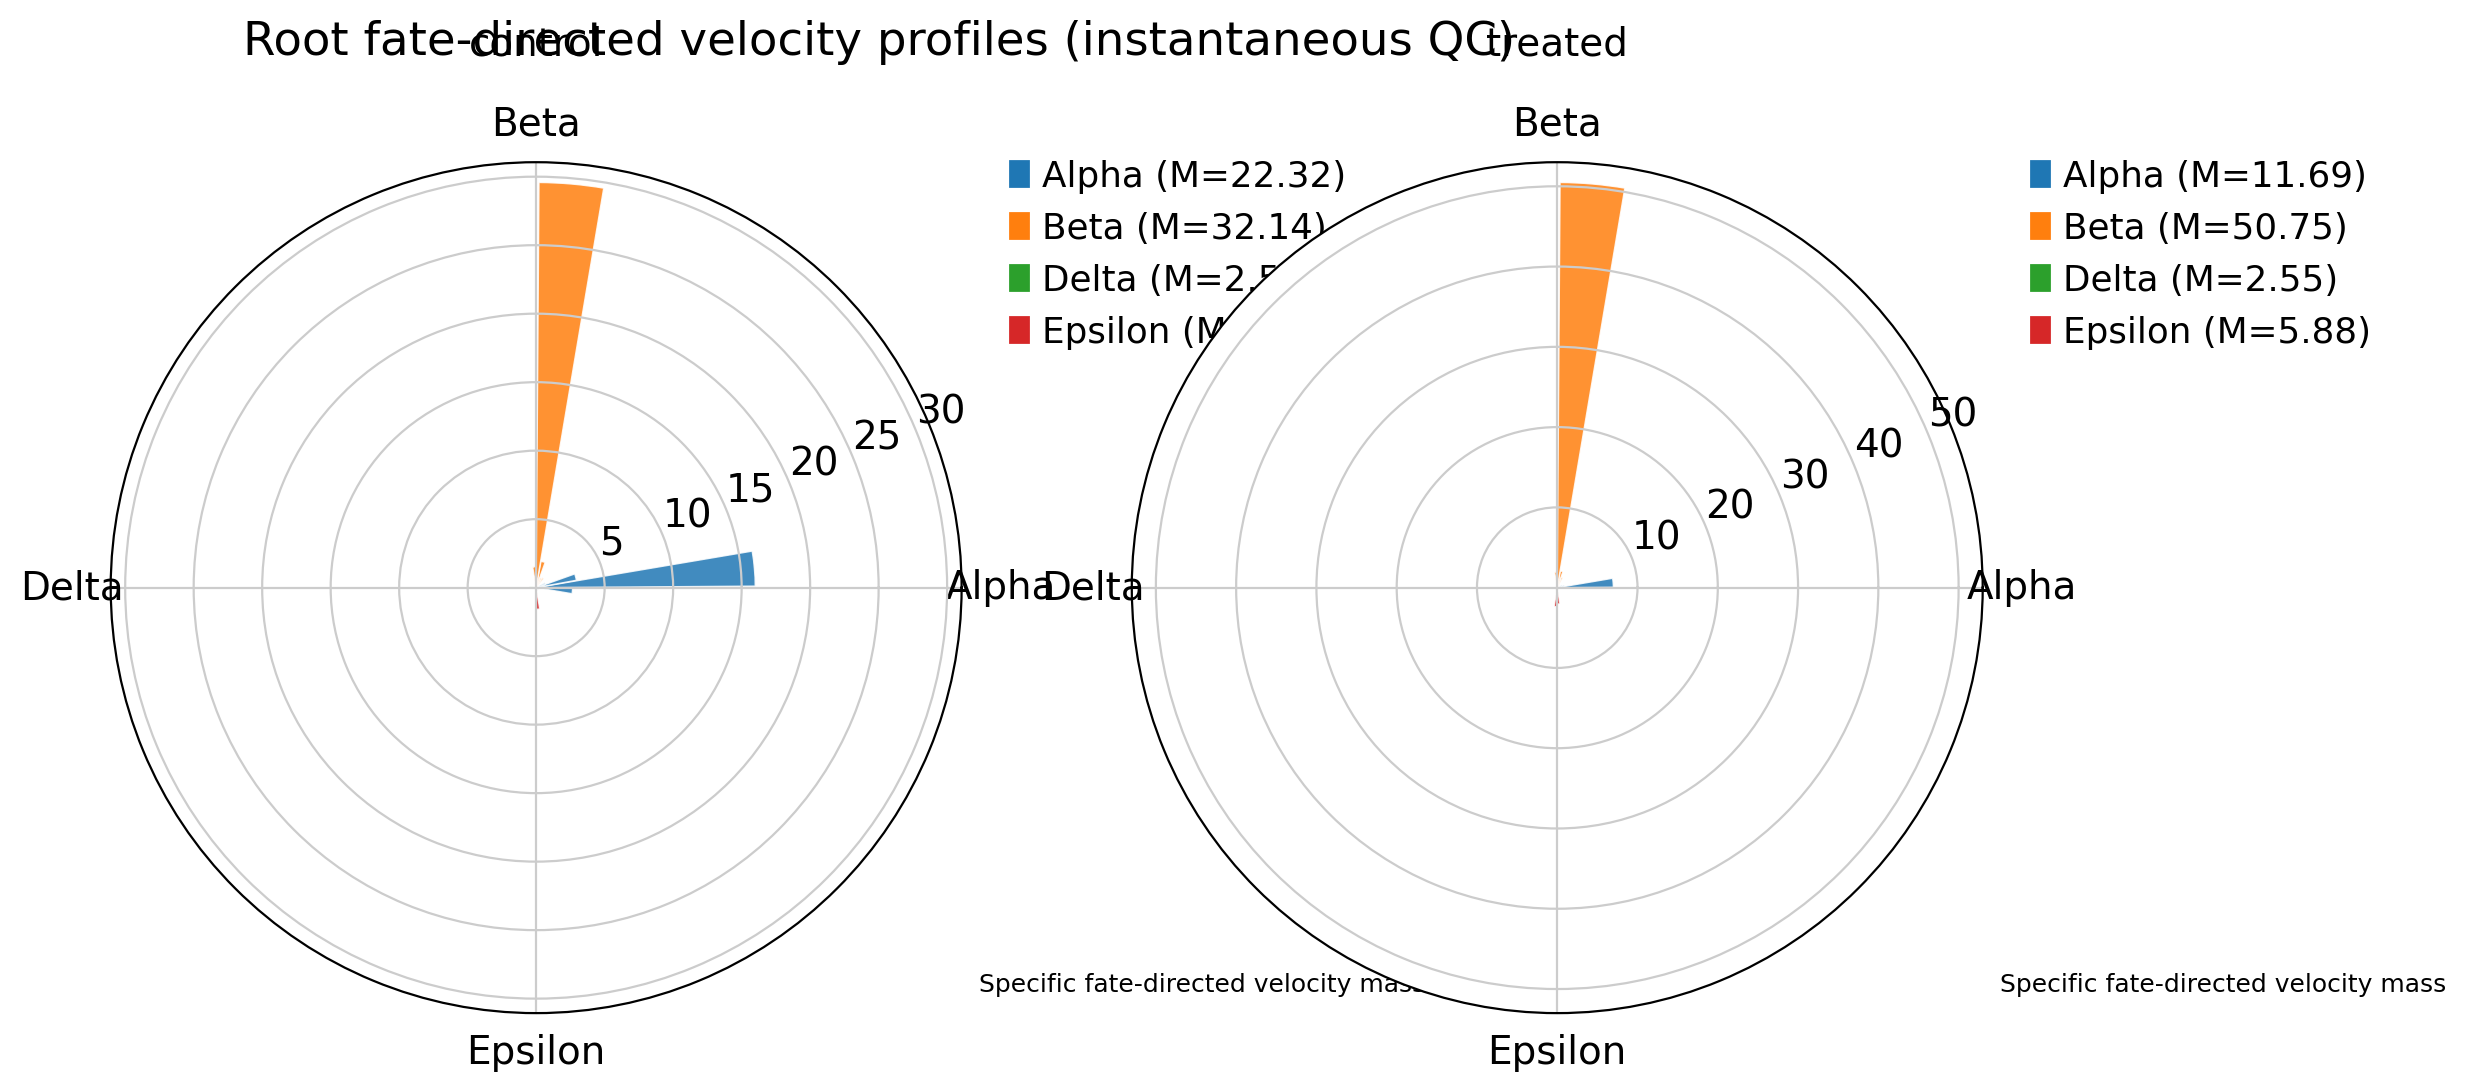

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pair.plot_pseudotime_trends(
    results,
    pseudotime_key=ORDERING_KEY,
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    n_bins=8,
    show_replicates=True,
    ax=axes[0],
)
pair.plot_pseudotime_trends(
    results,
    pseudotime_key=ORDERING_KEY,
    metric="signed_progression",
    n_bins=8,
    show_replicates=True,
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ordering_trends.png", dpi=200, bbox_inches="tight")
plt.show()

# Root branch roses summarize instantaneous fate-directed velocity after
# removing incoming-root progression. They are QC views, not discounted
# future-fate probabilities. Use an independent pooled scorer.
display_pair = scCS.PairScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key=OBS_KEY,
    condition_obs_key=CONDITION_KEY,
    replicate_obs_key=REPLICATE_KEY,
    condition_order=list(CONDITIONS),
)
display_pair.build_embedding(ordering_metric=ORDERING_KEY, verbose=False)
display_pair.fit(
    transition_matrix=analysis_transition,
    scoring_mode="instantaneous",
    transition_scope="pooled",
    verbose=False,
)
display_results = display_pair.score_all_conditions(
    population="root",
    min_cells=1,
    min_replicates=1,
)
rose_figure = display_pair.plot_rose_grid(
    display_results,
    population="root",
    mode="branch",
    n_bins=36,
    ncols=2,
    title="Root fate-directed velocity profiles (instantaneous QC)",
)
rose_figure.savefig(OUTPUT_DIR / "display_velocity_rose_grid.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. Gene expression across conditions on a shared scale


Resolved genes: ['Ins1', 'Ins2', 'Gcg', 'Sst', 'Ghrl', 'Neurog3']
Missing genes: []


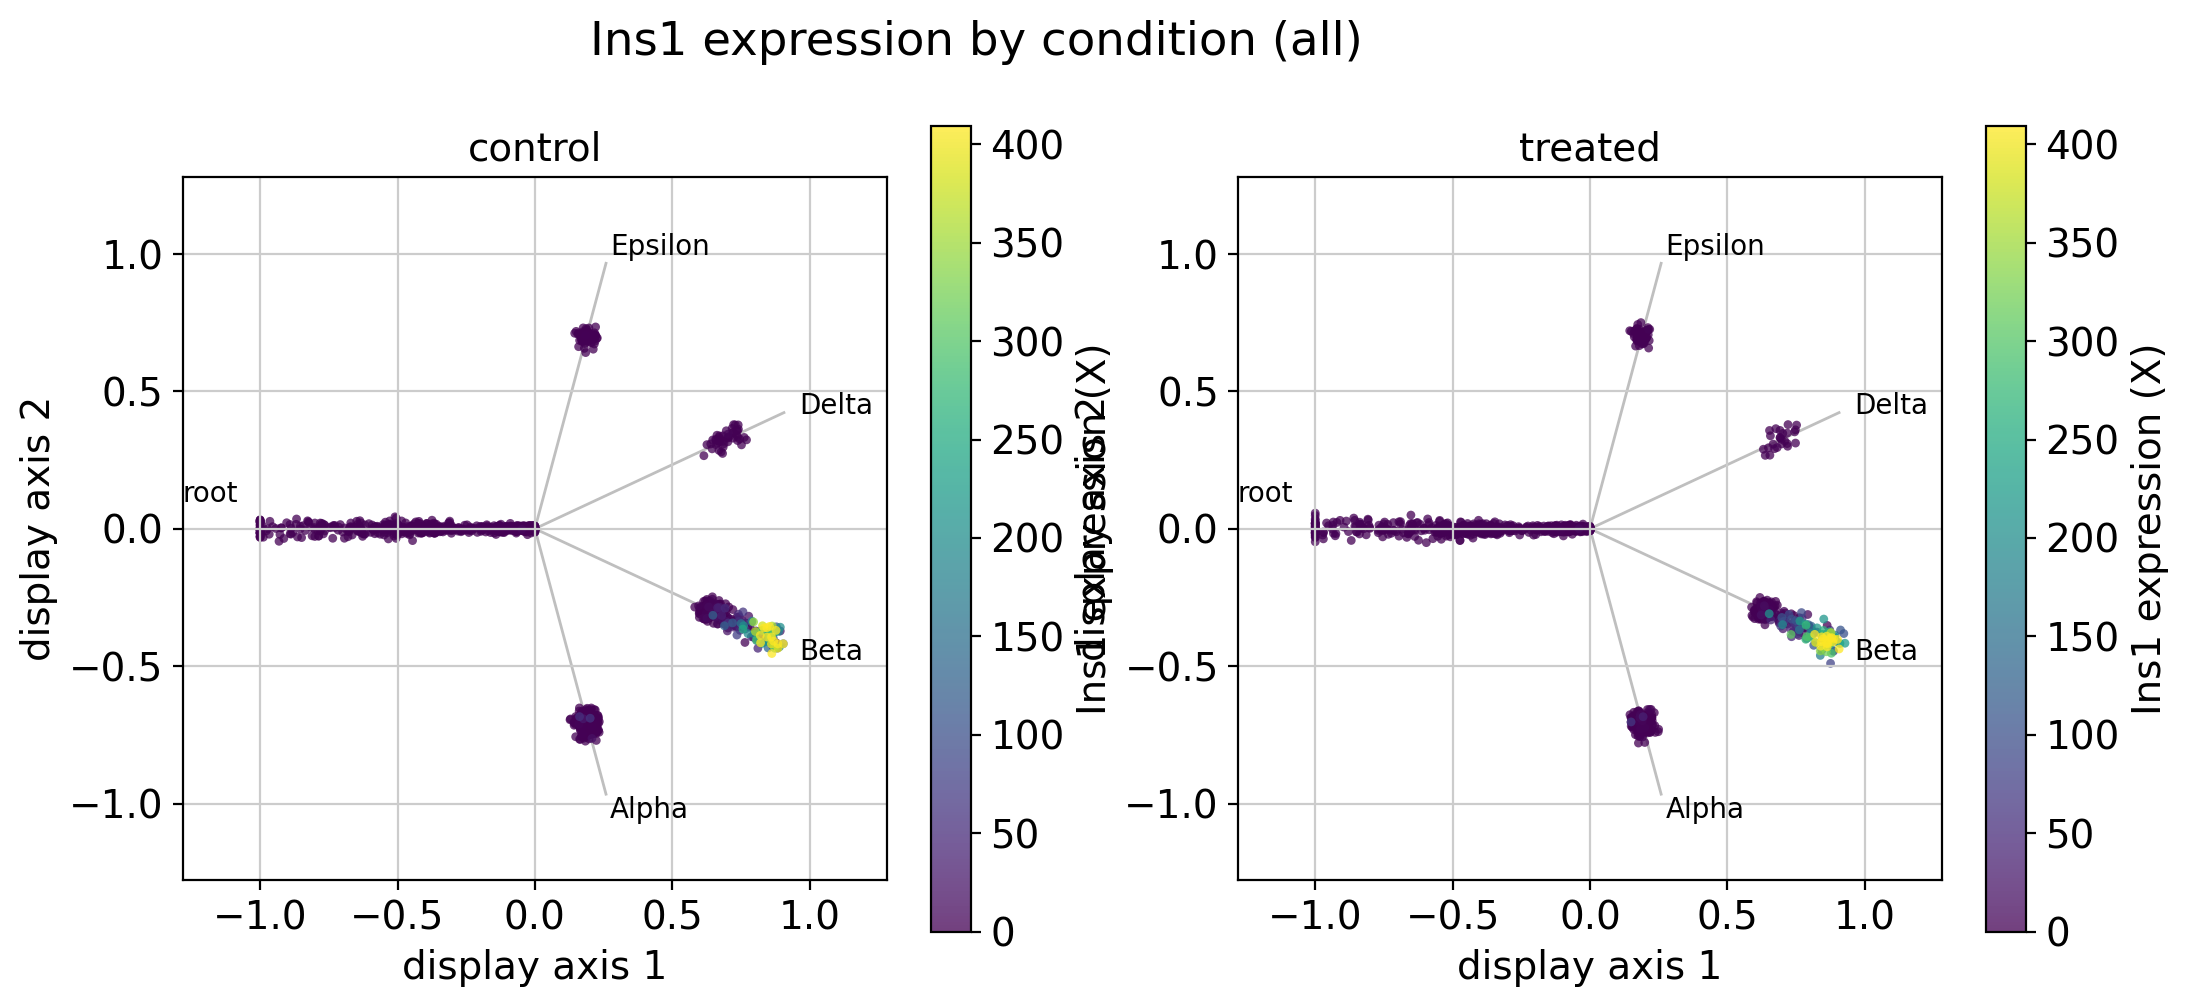

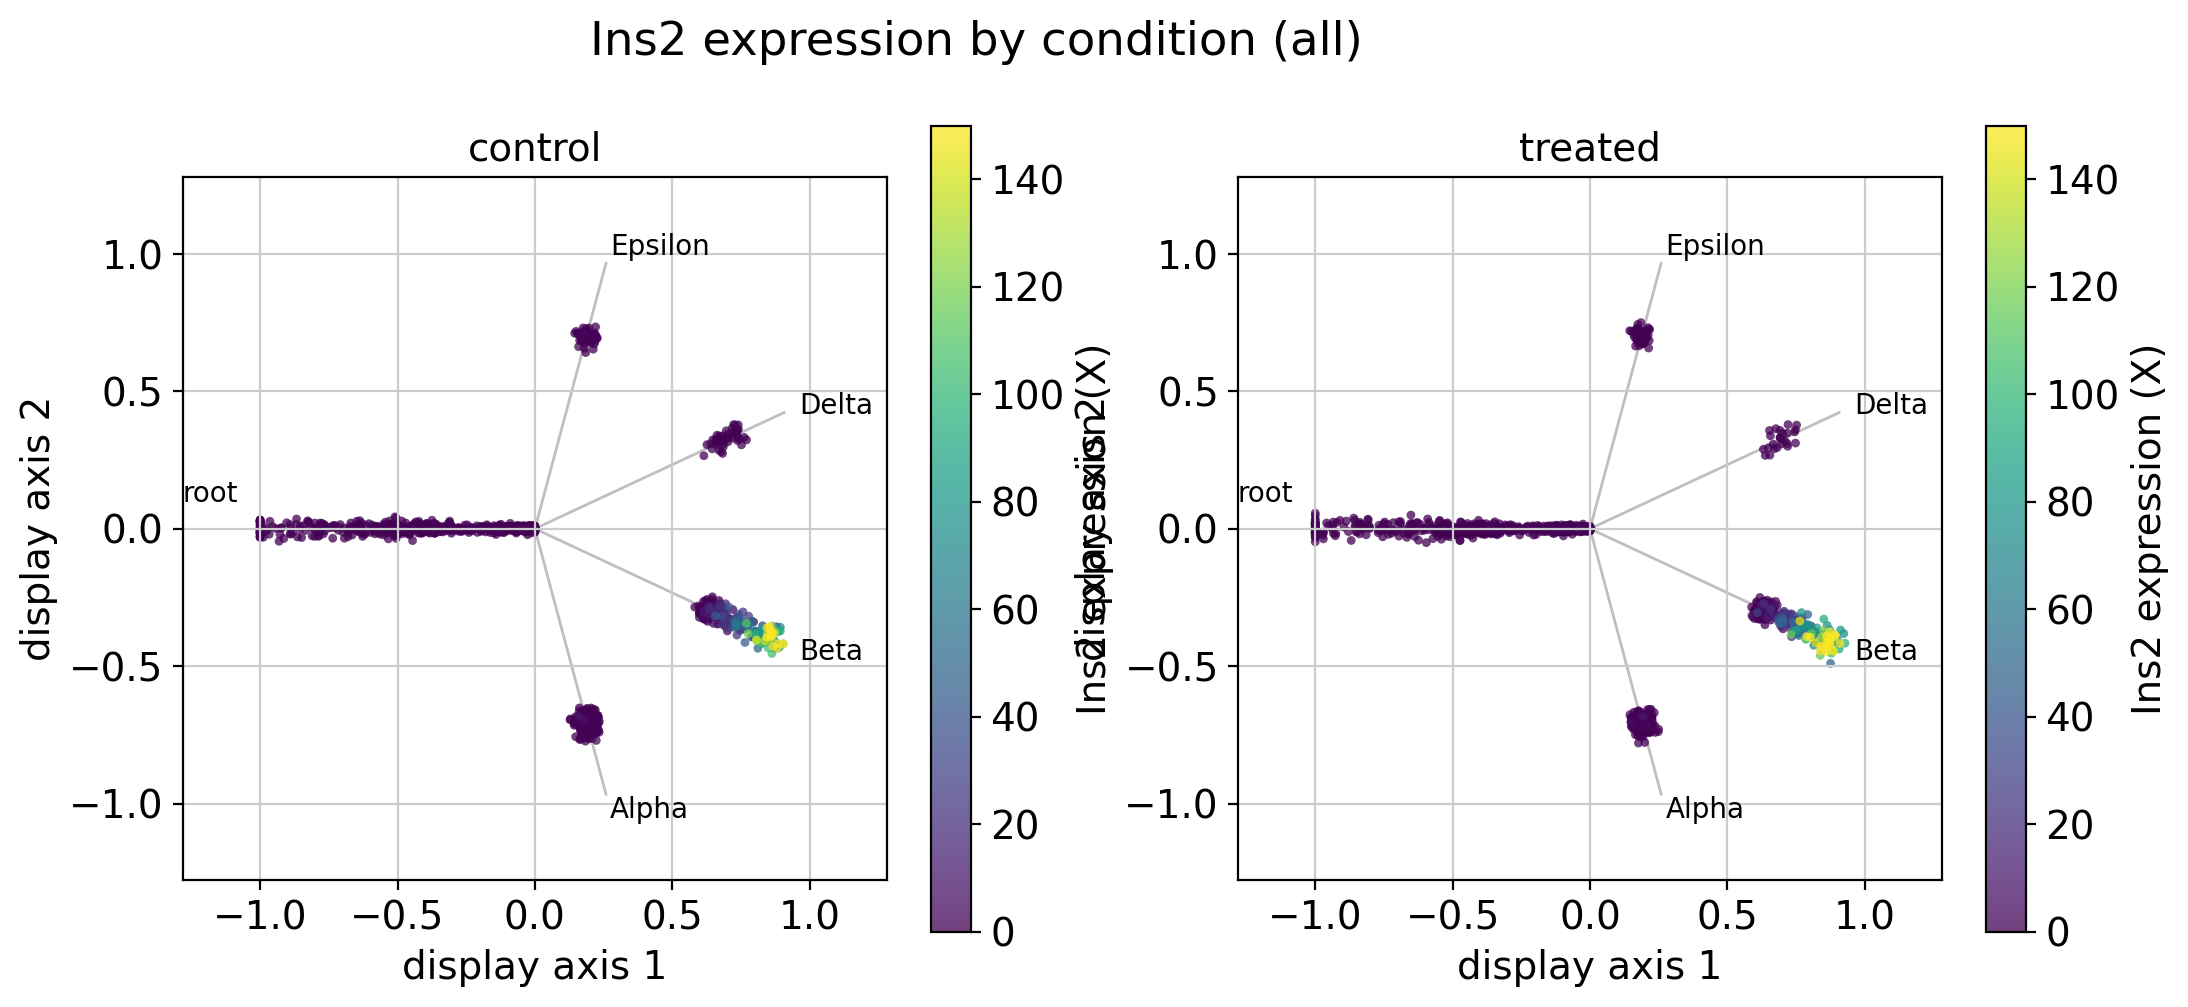

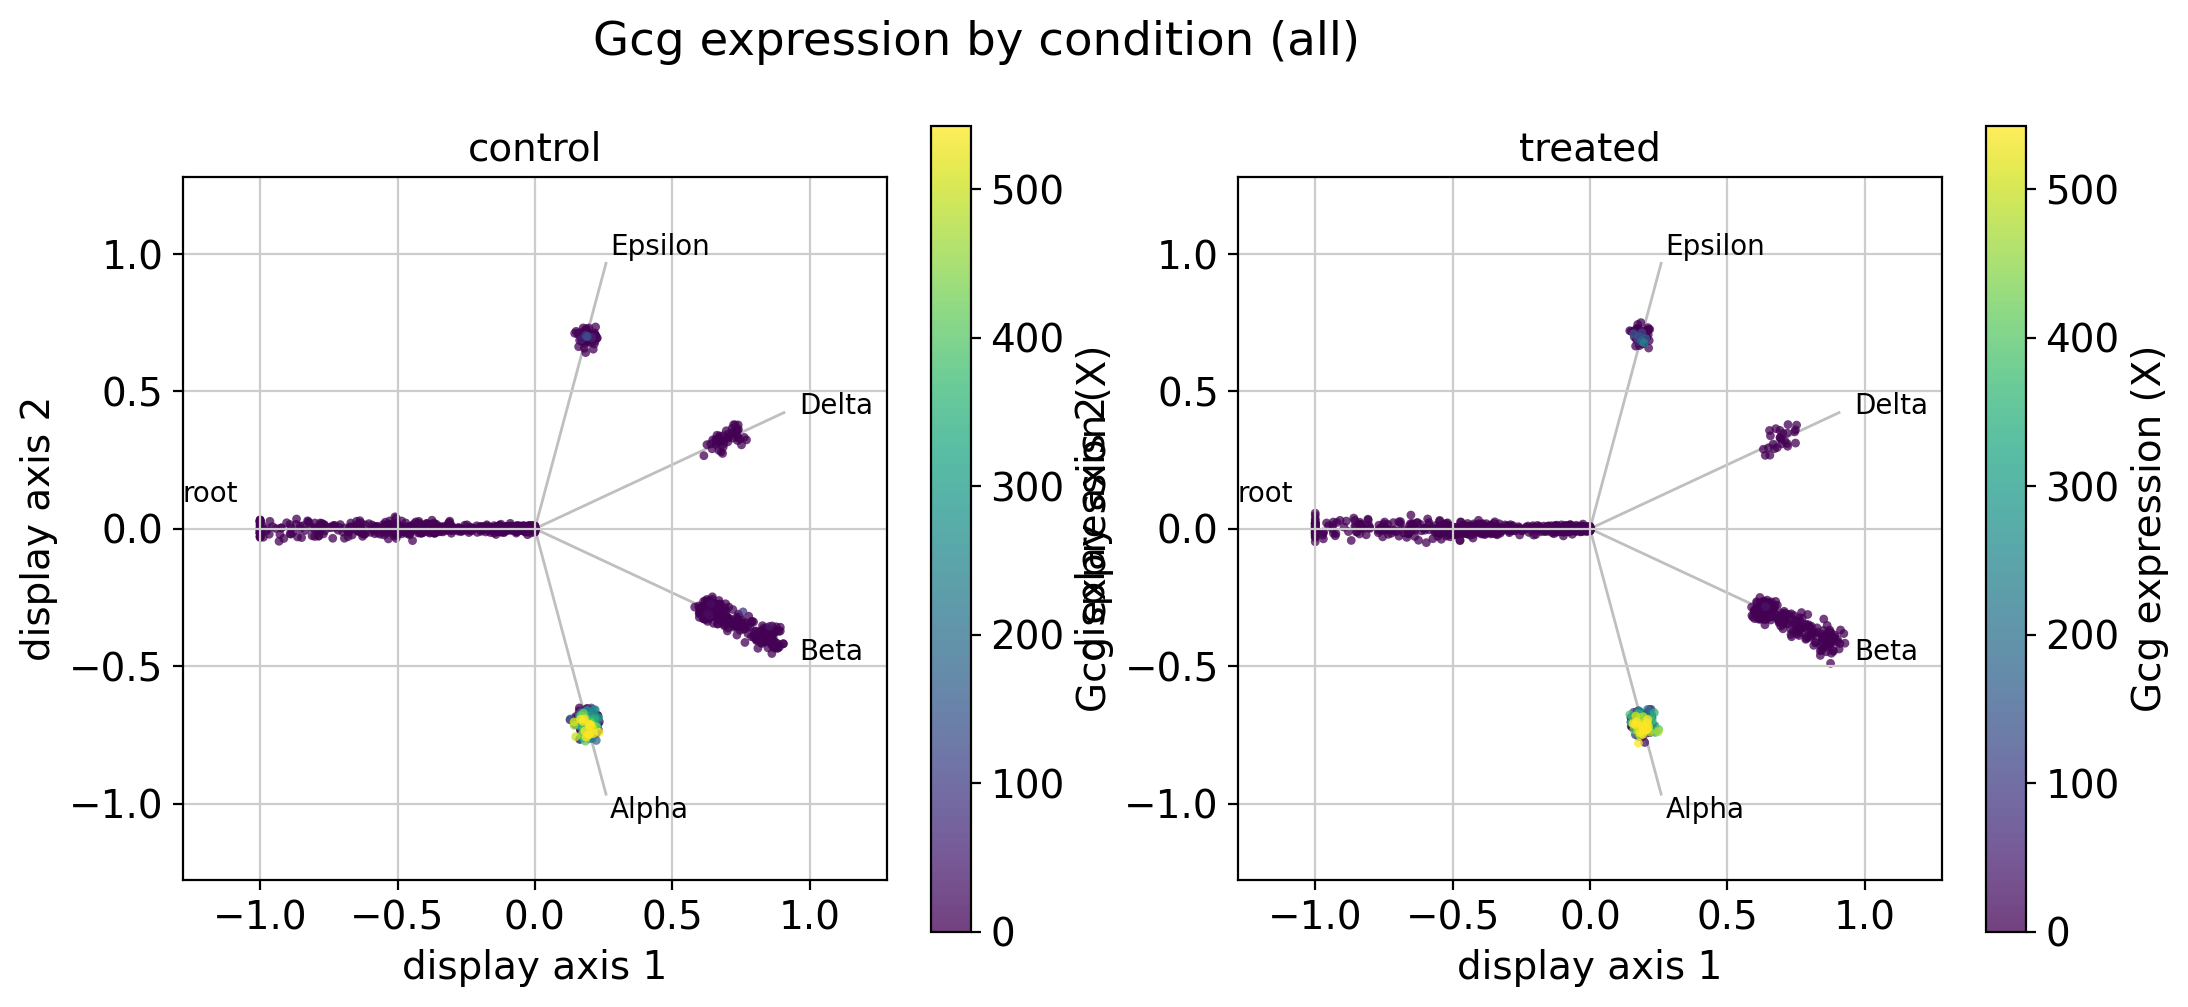

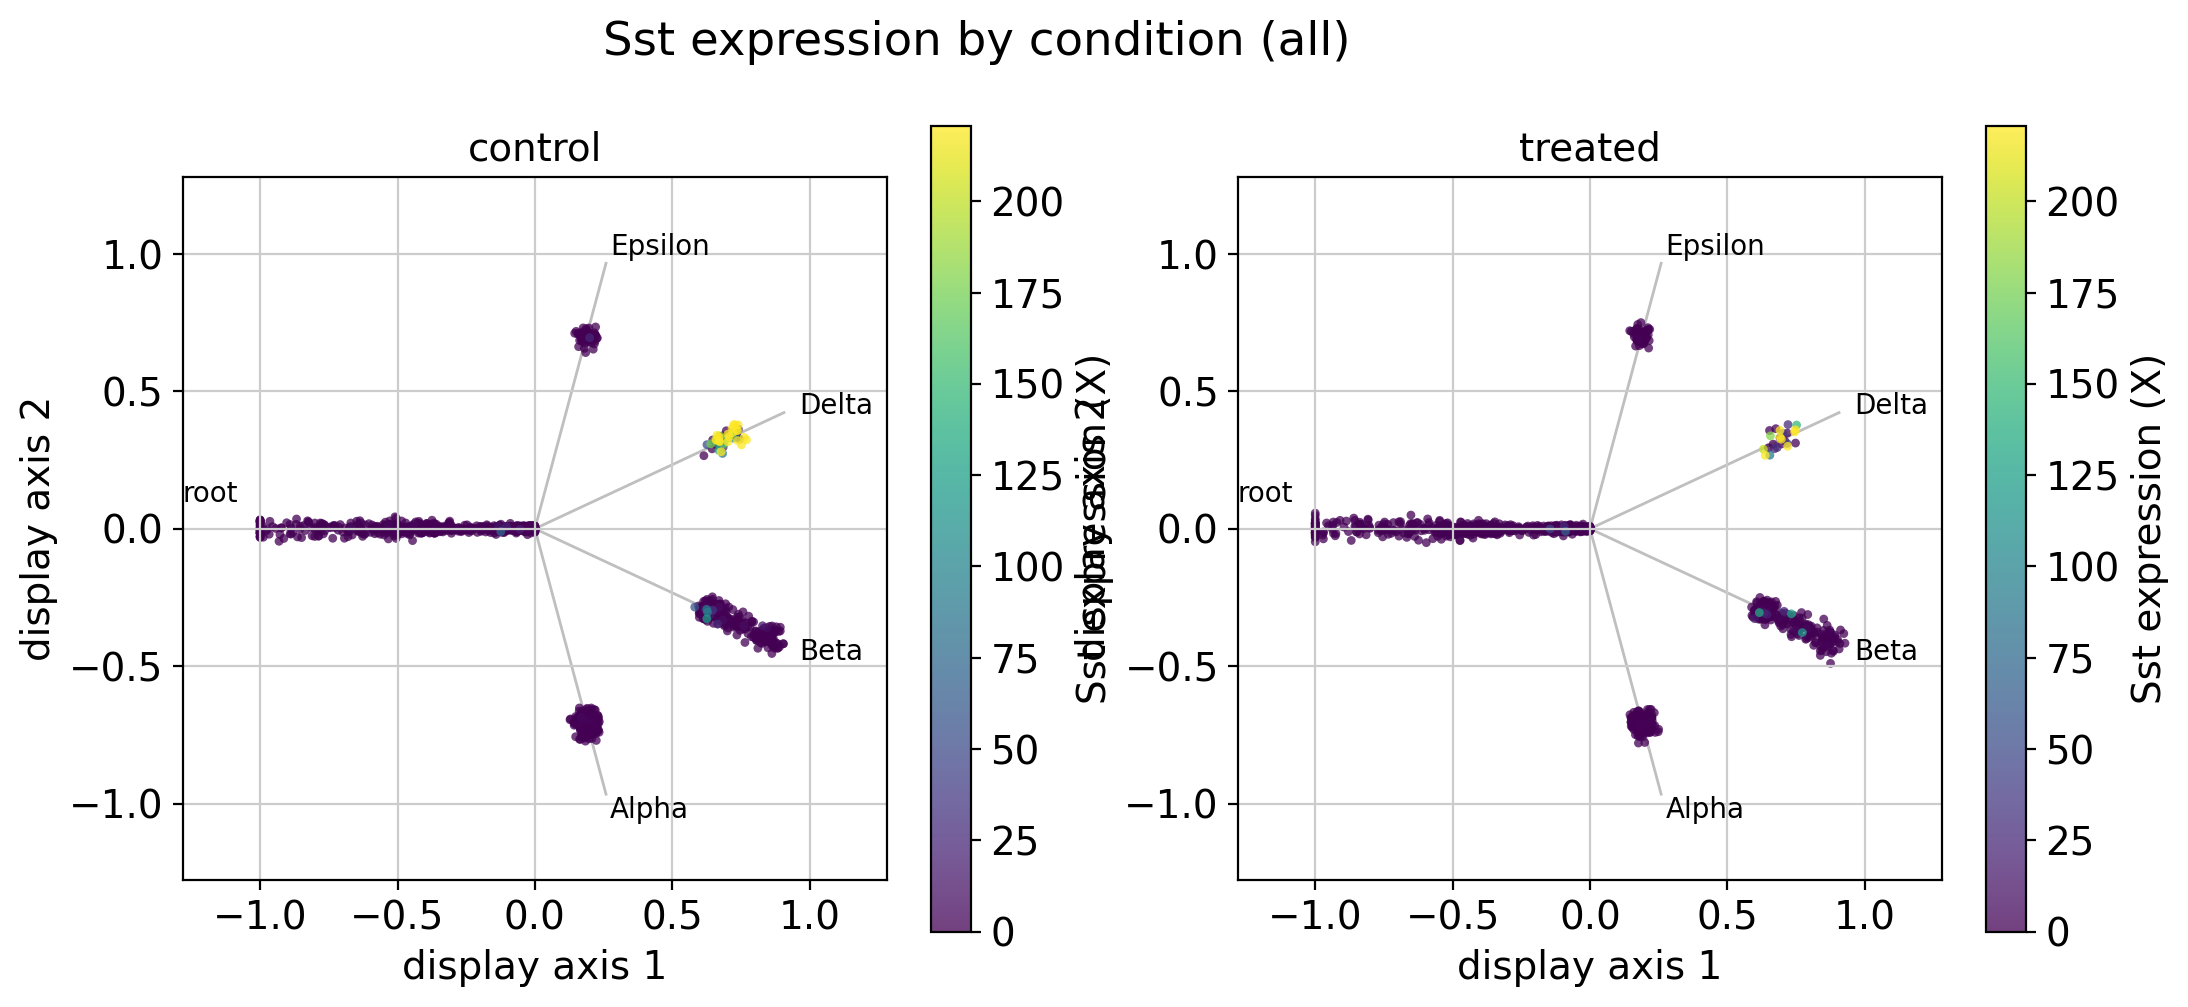

In [18]:
gene_candidates = ["Ins1", "Ins2", "Gcg", "Sst", "Ghrl", "Neurog3"]
genes, missing_genes = resolve_present_genes(adata, gene_candidates)
print("Resolved genes:", genes)
print("Missing genes:", missing_genes)
for gene in genes[:4]:
    figure = pair.plot_gene_expression_star_grid(
        gene,
        results,
        population="all",
        shared_scale=True,
        ncols=2,
    )
    figure.savefig(
        OUTPUT_DIR / f"gene_expression_{gene}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 16. Optional transition-scope sensitivity


In [19]:
if RUN_SCOPE_SENSITIVITY:
    scope_tables = []
    for scope in ("pooled", "condition", "replicate"):
        scope_pair = scCS.PairScorer(
            adata,
            root=ROOT,
            branches=FATES,
            obs_key=OBS_KEY,
            condition_obs_key=CONDITION_KEY,
            replicate_obs_key=REPLICATE_KEY,
            condition_order=list(CONDITIONS),
        )
        scope_pair.build_embedding(ordering_metric=ORDERING_KEY, verbose=False)
        scope_pair.fit(
            transition_matrix=analysis_transition,
            transition_scope=scope,
            scoring_mode="future_fate",
            future_fate_options=FUTURE_OPTIONS,
            verbose=False,
        )
        table = scope_pair.transition_scope_summary(population="root")
        table["transition_scope"] = scope
        scope_tables.append(table)
    scope_summary = pd.concat(scope_tables, ignore_index=True)
    display(scope_summary)
    scope_summary.to_csv(OUTPUT_DIR / "transition_scope_sensitivity.csv", index=False)
else:
    print("Set RUN_SCOPE_SENSITIVITY=True to compare pooled/blocked graphs.")

Set RUN_SCOPE_SENSITIVITY=True to compare pooled/blocked graphs.


## 17. Optional fail-closed mixed-model sensitivity


In [20]:
if RUN_MIXED_MODEL_SENSITIVITY:
    mixed = pair.fit_mixed_model(
        metric="future_fate_affinity",
        fate=TARGET_FATE,
        results=results,
        on_invalid="return",
    )
    display(mixed)
    mixed.to_csv(OUTPUT_DIR / "mixed_model_sensitivity.csv", index=False)
else:
    print("Permutation and hierarchical bootstrap are the primary inference.")

Permutation and hierarchical bootstrap are the primary inference.


## 18. Export analysis objects and statistical tables


In [21]:
pair.result.write_to_adata(adata)
adata.write_h5ad(OUTPUT_DIR / "pair_scorer_analysis.h5ad")
target_affinity_stats.to_csv(OUTPUT_DIR / "primary_target_affinity_test.csv", index=False)
target_contribution_stats.to_csv(
    OUTPUT_DIR / "primary_target_contribution_test.csv",
    index=False,
)
print("Saved outputs to", OUTPUT_DIR.resolve())

Saved outputs to /home/emil/notebooks/08-tutorials/tutorial_outputs/pancreas_pair


## 19. Interpretation and real-study adaptation


In the controlled demonstration, the expected primary effect is increased future
Beta affinity/contribution in `treated`. Reach or signed progression can also
change and must be reported rather than assumed constant. Alpha, Delta, and
Epsilon remain biologically complex branches.


For real data:

1. set `DEMO_MODE=False`;
2. provide genuine condition and independent replicate columns;
3. use the original velocity transition matrix without controlled reweighting;
4. verify condition balance, transition-scope assumptions, and replicate counts;
5. report effect sizes, raw and adjusted p-values, replicate counts, and confidence
   intervals;
6. do not treat cells as biological replicates.
